# FFQ Dietary Analysis — MSc AgriFood, Sustainability and Technology
## University of Galway

**Research question:** To what extent does diet type shape the nutritional quality and dietary sustainability of householders' diets in Galway, and is there a relationship between sustainability and nutritional quality?

**Data sources:**
- Nutritics Research Edition (GB23 database) — daily nutrient totals per participant
- EPIC-Norfolk FFQ (FETA methodology) — n=23 analytic participants
- ELI 2.0: Stubbendorff et al. (2026), Lancet Planetary Health
- DRVs: SACN (2017) / COMA

**Analysis steps:**
1. Load data (Nutritics export + FFQ Excel)
2. Calculate ELI 2.0 scores from FFQ frequency responses
3. Calculate MAR from Nutritics nutrient output (extended: 16 micronutrients + protein + fibre; MAR_16 retained as reference)
4. Statistical analysis: group comparisons and correlation
5. Figures

## Section 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
!pip install gdown -q
import gdown
import os

files = {
    '1ddapFubQY4J_AJU5ORtLgVgfh-E1caVP': 'Nutritics_Final.csv',
    '1ocr0-0iEWxhHjNVTDemdTPvZJ3gaD1hF': 'FoodSystemsGalway.csv',
    '161CmhqJt-QnGHhHOgrkwyszeg5kxvtVw': 'Food_Frequency_Questionnaire_data_2.xlsx'
}

for file_id, name in files.items():
    # Force re-download if file is missing OR empty (0 bytes)
    if not os.path.exists(name) or os.path.getsize(name) == 0:
        gdown.download(id=file_id, output=name, quiet=False)

# Verify all files downloaded correctly
print("File check:")
all_ok = True
for name in files.values():
    if os.path.exists(name) and os.path.getsize(name) > 0:
        print(f"{name}: {os.path.getsize(name):,} bytes")
    else:
        print(f"{name}: MISSING OR EMPTY")
        all_ok = False

if all_ok:
    print("\nAll 3 files downloaded successfully.")
else:
    print("\nOne or more files failed to download.")

File check:
Nutritics_Final.csv: 99,009 bytes
FoodSystemsGalway.csv: 2,643,141 bytes
Food_Frequency_Questionnaire_data_2.xlsx: 49,225 bytes

All 3 files downloaded successfully.


## Section 2: Load Data

### 2a. Load Nutritics Batch Export (Daily Nutrient Totals)
Export type: Daily Totals and Averages, all 23 participants, from Nutritics Research Edition (GB23 database).

In [3]:
import csv

# Read all lines from the file
with open('Nutritics_Final.csv', 'r', encoding='utf-8-sig') as f:
    lines = f.readlines()

# Line 0 = sep=,   Line 1 = nutrient names   Line 2 = col labels   Line 3+ = data
nutrient_names = list(csv.reader([lines[1]]))[0]
col_labels     = list(csv.reader([lines[2]]))[0]

# Build column names
col_names = []
for i, (lab, nut) in enumerate(zip(col_labels, nutrient_names)):
    if lab and lab not in ('AVG', ''):
        col_names.append(lab.strip())
    elif nut and nut not in ('', 'GL'):
        col_names.append(nut.strip())
    else:
        col_names.append(f'col_{i}')

# Extract the 23 data rows
data_rows = []
for line in lines[3:]:
    row = list(csv.reader([line]))[0]
    if row and row[0] and row[0] not in ('', 'ID No'):
        pid_digits = ''.join(filter(str.isdigit, row[0]))
        if pid_digits:
            data_rows.append(row)
    if len(data_rows) == 23:
        break

# Build dataframe
nutritics = pd.DataFrame(data_rows, columns=col_names[:len(data_rows[0])])
nutritics['PID'] = nutritics['ID No'].str.extract(r'(\d+)').astype(int)

# Convert nutrient columns to numbers
for col in nutritics.columns:
    if col not in ['ID No', 'First Name', 'Surname', 'Log Name',
                   'Log start date', 'Log end date', 'DOB', 'PID']:
        nutritics[col] = pd.to_numeric(nutritics[col], errors='coerce')

print(f"Participants loaded: {len(nutritics)}")
print(f"PIDs: {sorted(nutritics['PID'].tolist())}")

Participants loaded: 23
PIDs: [100, 119, 200, 222, 339, 371, 424, 428, 432, 453, 475, 629, 661, 684, 702, 729, 803, 850, 892, 901, 935, 968, 986]


### 2b. Load FFQ Frequency Response Data
EPIC-Norfolk style FFQ (FETA methodology). Contains frequency responses for 130 food lines across 23 participants.

In [4]:
import openpyxl

# Read FFQ Excel file
wb = openpyxl.load_workbook('Food_Frequency_Questionnaire_data_2.xlsx', data_only=True)
ws = wb.active
rows = list(ws.iter_rows(values_only=True))

print(f"Total rows: {len(rows)}")
print(f"Row 5 (participant IDs): {rows[4][:8]}")

Total rows: 234
Row 5 (participant IDs): (None, 'Participant ID #', 655, 873, 803, 850, 453, 119)


### 2c. Identify Analytic Participants
Exclude empty columns and P161 (no height/weight data available).

In [5]:
# Identify the 23 analytic participants (excluding empty columns and P161)
empty_pids = {655, 873, 741, 791, 321, 528, 109, 123, 161}

pid_row = rows[4]
analytic_cols = [
    (c, pid_row[c])
    for c in range(2, len(pid_row))
    if pid_row[c] is not None and pid_row[c] not in empty_pids
]

participants = [pid for c, pid in analytic_cols]
col_map = {pid: c for c, pid in analytic_cols}

print(f"Analytic participants: n={len(participants)}")
print(f"PIDs: {participants}")

Analytic participants: n=23
PIDs: [803, 850, 453, 119, 684, 428, 475, 702, 968, 892, 629, 986, 935, 100, 371, 424, 200, 729, 222, 432, 901, 661, 339]


## Section 3: Calculate ELI 2.0 Dietary Sustainability Score
Reference: Stubbendorff et al. (2026), EAT-Lancet Index 2.0, Lancet Planetary Health.
15 food group components scored 0–3 each. Maximum total = 45 points.

### 3a. Extract FFQ Frequency Responses

In [6]:
# Extract frequency responses for all 130 FFQ food lines (rows 5-134)
# Row index 5 = first food line, row index 134 = last food line

food_labels = []
food_responses = {}

for i in range(5, 135):
    label = rows[i][1]
    if label is None:
        continue
    food_labels.append(label)
    food_responses[label] = {}
    for c, pid in analytic_cols:
        food_responses[label][pid] = rows[i][c]

print(f"Food lines extracted: {len(food_labels)}")
print(f"\nFirst 5 food labels:")
for label in food_labels[:5]:
    print(f"  {label}")
print(f"\nSample responses for beef (P803, P850, P453):")
beef = food_responses['beef_roast_steak_mince_stew_casserole']
for pid in [803, 850, 453]:
    print(f"  P{pid}: {beef[pid]}")

Food lines extracted: 130

First 5 food labels:
  beef_roast_steak_mince_stew_casserole
  beefburgers
  pork_roast_chops_stew_slices
  lamb_roast_chops_stew
  chicken_or_other_poultry

Sample responses for beef (P803, P850, P453):
  P803: never or less than once/month
  P850: 1-3 per month
  P453: 2-3 per day


### 3b. Convert Frequency Responses to Daily Multipliers
EPIC-Norfolk 9-category scale. Midpoint used for range categories.

In [7]:
# Convert frequency responses to daily multipliers
# Based on EPIC-Norfolk 9-category scale (FETA methodology)
# Midpoint of each band used where a range is given

FREQ_MULT = {
    'never or less than once/month': 0.0,
    '1-3 per month':                 2/30,   # midpoint = 2 per month
    'once a week':                   1/7,
    '2-4 per week':                  3/7,    # midpoint = 3 per week
    '5-6 per week':                  5.5/7,  # midpoint = 5.5 per week
    'once a day':                    1.0,
    '2-3 per day':                   2.5,    # midpoint = 2.5 per day
    '4-5 per day':                   4.5,    # midpoint = 4.5 per day
    '6+ per day':                    6.0,    # conservative estimate
}

# Test the conversion
test_responses = ['never or less than once/month', '1-3 per month',
                  'once a week', '2-4 per week', 'once a day']

print("Frequency conversion check:")
for resp in test_responses:
    mult = FREQ_MULT.get(resp, 0)
    print(f"  '{resp}' -> {mult:.4f} times/day")

Frequency conversion check:
  'never or less than once/month' -> 0.0000 times/day
  '1-3 per month' -> 0.0667 times/day
  'once a week' -> 0.1429 times/day
  '2-4 per week' -> 0.4286 times/day
  'once a day' -> 1.0000 times/day


### 3c. FETA Portion Sizes
Source: Mulligan et al. (2014), FETA portion size document.
Where multiple sub-foods exist per FFQ line, a consolidated representative food and averaged portion were used (see consolidation decisions record).

In [8]:
# FETA portion sizes (g per serving) for each FFQ line

PORTIONS = {
    'beef_roast_steak_mince_stew_casserole': 99,
    'beefburgers':                           100,
    'pork_roast_chops_stew_slices':          92,
    'lamb_roast_chops_stew':                 85,
    'chicken_or_other_poultry':              57.5,
    'bacon':                                 41,
    'ham':                                   47,
    'corned_beef_spam_luncheon_meats':       30,
    'sausages':                              30,
    'savoury_pies':                          18.3,
    'liver_liver_paté_liver sausage':        20,
    'fried_fish_in_batter':                  160,
    'fish_fingers_fish_cakes':               58,
    'other_white_fish_fresh_or_frozen':      115,
    'oily_fish_fresh_canned':                19,
    'shellfish':                             20,
    'fish_roe_or_taramasalata':              45,
    'white_bread_and_rolls':                 30,
    'brown_bread_and_rolls':                 30,
    'wholemeal_bread_and_rolls':             35,
    'cream_crackers_or_cheese_biscuits':     10,
    'crispbread':                            10,
    'porridge_or_readybrek':                 137,
    'breakfast_cereal ':                     30,
    'boiled_mashed_instant_or_jacket_potatoes': 125,
    'chips':                                 63,
    'roast_potatoes':                        126,
    'potato_salad':                          15,
    'white_rice':                            150,
    'brown_rice':                            140,
    'white_or_green_pasta':                  150,
    'wholemeal_pasta':                       180,
    'lasagne_or_moussaka':                   100,
    'pizza':                                 75,
    'Single or sour cream (tablespoon)':     20,
    'Double or clotted cream (tablespoon)':  20,
    'Low fat yogurt, fromage frais (125g carton)': 42,
    'Full fat or Greek yogurt (125g carton)': 63,
    'Dairy desserts (125g carton)':          63,
    'Cheese, eg. Cheddar, Brie, Edam (medium serving)': 11.3,
    'Cottage cheese, low fat soft cheese (medium serving)': 60,
    'Eggs as boiled, friend, scrambled, etc. (one) ': 50,
    'Quiche (medium serving)':               75,
    'Low calorie, low fat salad cream (tablespoon)': 30,
    'Salad cream, mayonnaise (tablespoon)':  15,
    'French dressing (tablespoon)':          15,
    'Other salad dressing (tablespoon)':     30,
    'Butter (teaspoon)':                     10,
    'Block or hard margarine, eg. Stork, Krona (teaspoon)': 10,
    'Polyunsaturated margarine, eg. Flora, sunflower, soya spreads (teaspoon)': 10,
    'Soft margarines,including olive oil based and dairy spreads, eg. Blue Band, Clover (teaspoon)': 10,
    'Low fat spreads (less than 60% fat), eg. Outline, Gold (teaspoon)': 10,
    'Very low fat spread (less than 30% fat) (teaspoon)': 10,
    'Sweet biscuits, chocolate , eg. digestive (one)': 17,
    'Sweet biscuits, plain, eg. Nice, ginger (one)': 8,
    'Cakes eg. fruit, sponge, home baked':   34,
    'Cakes eg. fruit, sponge, ready made':   34,
    'Buns, pastries eg. scones, flapjacks, home baked': 27,
    'Buns, pastries eg. croissants, doughnuts, ready made': 32,
    'Fruit pies, tarts, crumbles, home baked': 67.5,
    'Fruit pies, tarts, crumbles, ready made': 65,
    'Sponge puddings, home baked':           170,
    'Sponge puddings, ready made':           170,
    'Milk puddings, eg. rice, custard, trifle': 65,
    'Ice cream, choc ices':                  27,
    'Chocolates, single or squares':         8,
    'Chocolate snack bars eg. Mars, Crunchie': 25,
    'Sweets, toffees, mints':               10,
    'Sugar added to tea, coffee cereal (teaspoon)': 6,
    'Crisps or other packet snacks, eg. Wotsits': 30,
    'Peanuts or other nuts':                 15,
    'Vegetable soups (bowl)':               200,
    'Meat soups (bowl)':                    100,
    'Sauces, eg. white sauce, cheese sauce, gravy (tablespoon)': 15,
    'Tomato ketchup (tablespoon)':          30,
    'Pickles, chutney (tablespoon)':        20,
    'Marmite, Bovril (teaspoon)':           9,
    'Jam, marmalade, honey (teaspoon)':     18,
    'Peanut butter (teaspoon)':             19,
    'Tea (cup)':                            190,
    'Coffee, instant or ground (cup)':      190,
    'Coffee, decaffeinated (cup)':          190,
    'Coffee whitener, eg. Coffee-mate (teaspoon)': 3,
    'Cocoa, hot chocolate (cup)':           12,
    'Horlicks, Ovaltine (cup)':             12,
    'Wine (glass)':                         125,
    'Beer, lager or cider (half pint)':     144,
    'Port, sherry, vermouth, liqueurs (glass)': 25,
    'Spirits, eg. gin, brandy, whisky, vodka (single)': 23,
    'Low calorie or diet fizzy soft drinks (glass)': 200,
    'Fizzy soft drinks, eg. Coca cola, lemonade (glass)': 100,
    'Pure fruit juice (100%) eg. orange, apple juice (glass)': 60,
    'Fruit squash or cordial (glass)':      40,
    'Apples (1 fruit)':                     120,
    'Pears (1 fruit)':                      60,
    'Oranges, satsumas, mandarins (1 fruit)': 120,
    'Grapefruit (half)':                    80,
    'Bananas (1 fruit)':                    100,
    'Grapes (medium serving)':              50,
    'Melon (1 slice)':                      180,
    '* Peaches, plums, apricots (1 fruit)': 10,
    '* Strawberries, raspberries, kiwi fruit (medium serving)': 13.3,
    'Tinned fruit (medium serving)':        60,
    'Dried fruit, eg. raisins, prunes (medium serving)': 8.3,
    'Carrots':                              32,
    'Spinach':                              75,
    'Broccoli, spring greens, kale':        40,
    'Brussels sprouts':                     87,
    'Cabbage':                              30.3,
    'Peas':                                 31.5,
    'Green beans, broad beans, runner beans': 23.3,
    'Marrow, courgettes':                   36,
    'Cauliflower':                          110,
    'Parsnips, turnips, swedes':            37,
    'Leeks':                                76,
    'Onions':                               34,
    'Garlic':                               5,
    'Mushrooms':                            45,
    'Sweet peppers':                        13,
    'Beansprouts':                          42,
    'Green salad, lettuce, cucumber, celery': 11.7,
    'Watercress':                           17,
    'Tomatoes':                             57,
    'Sweetcorn':                            43,
    'Beetroot':                             48,
    'Coleslaw':                             20,
    'Avocado':                              70,
    'Baked beans':                          42,
    'Dried lentils, beans, peas':           35,
    'Tofu , soya meat, TVP, Vegeburger':    50,
}

print(f"Portion sizes defined: {len(PORTIONS)} food lines")
print(f"\nSample check:")
print(f"  Beef portion: {PORTIONS['beef_roast_steak_mince_stew_casserole']}g")
print(f"  Vegetables (carrots): {PORTIONS['Carrots']}g")
print(f"  Wholemeal bread: {PORTIONS['wholemeal_bread_and_rolls']}g")

Portion sizes defined: 130 food lines

Sample check:
  Beef portion: 99g
  Vegetables (carrots): 32g
  Wholemeal bread: 35g


### 3d. Calculate Daily Intake (g/day) per Food per Participant
Formula: g/day = frequency multiplier × portion size (g)

In [9]:
# Calculate g/day for each food for each participant
# Formula: g/day = frequency multiplier x portion size (g)

daily_grams = {}

for pid in participants:
    daily_grams[pid] = {}
    for label in food_labels:
        freq_response = food_responses[label].get(pid)
        freq_mult = FREQ_MULT.get(freq_response, 0)
        portion = PORTIONS.get(label, 0)
        daily_grams[pid][label] = round(freq_mult * portion, 3)

# Spot check
print("Spot check — P453 daily grams for first 5 foods:")
for label in food_labels[:5]:
    print(f"  {label}: {daily_grams[453][label]:.3f} g/day")

print(f"\nSpot check — beef g/day across 3 participants:")
for pid in [803, 850, 453]:
    freq = food_responses['beef_roast_steak_mince_stew_casserole'][pid]
    g = daily_grams[pid]['beef_roast_steak_mince_stew_casserole']
    print(f"  P{pid}: '{freq}' -> {g:.3f} g/day")

Spot check — P453 daily grams for first 5 foods:
  beef_roast_steak_mince_stew_casserole: 247.500 g/day
  beefburgers: 0.000 g/day
  pork_roast_chops_stew_slices: 13.143 g/day
  lamb_roast_chops_stew: 0.000 g/day
  chicken_or_other_poultry: 0.000 g/day

Spot check — beef g/day across 3 participants:
  P803: 'never or less than once/month' -> 0.000 g/day
  P850: '1-3 per month' -> 6.600 g/day
  P453: '2-3 per day' -> 247.500 g/day


### 3e. Map FFQ Lines to ELI 2.0 Components
Each FFQ food line assigned to its corresponding ELI 2.0 food group component.

In [10]:
# Map FFQ food lines to ELI 2.0 components
# Reference: Stubbendorff et al. (2026), Lancet Planetary Health

ELI_COMPONENTS = {
    'Vegetables': [
        'Vegetable soups (bowl)',
        'Carrots', 'Spinach', 'Broccoli, spring greens, kale',
        'Brussels sprouts', 'Cabbage', 'Peas',
        'Green beans, broad beans, runner beans', 'Marrow, courgettes',
        'Cauliflower', 'Parsnips, turnips, swedes', 'Leeks', 'Onions',
        'Garlic', 'Mushrooms', 'Sweet peppers', 'Beansprouts',
        'Green salad, lettuce, cucumber, celery', 'Watercress',
        'Tomatoes', 'Sweetcorn', 'Beetroot', 'Coleslaw', 'Avocado'
    ],
    'Fruits': [
        'Pure fruit juice (100%) eg. orange, apple juice (glass)',
        'Apples (1 fruit)', 'Pears (1 fruit)',
        'Oranges, satsumas, mandarins (1 fruit)', 'Grapefruit (half)',
        'Bananas (1 fruit)', 'Grapes (medium serving)', 'Melon (1 slice)',
        '* Peaches, plums, apricots (1 fruit)',
        '* Strawberries, raspberries, kiwi fruit (medium serving)',
        'Tinned fruit (medium serving)',
        'Dried fruit, eg. raisins, prunes (medium serving)'
    ],
    'Legumes': [
        'Baked beans',
        'Dried lentils, beans, peas',
        'Tofu , soya meat, TVP, Vegeburger'
    ],
    'Tree_nuts_and_peanuts': [
        'Peanuts or other nuts',
        'Peanut butter (teaspoon)'
    ],
    'Wholegrains': [
        'wholemeal_bread_and_rolls',
        'crispbread',
        'porridge_or_readybrek',
        'brown_rice',
        'wholemeal_pasta'
    ],
    'Fish_and_shellfish': [
        'fried_fish_in_batter',
        'fish_fingers_fish_cakes',
        'other_white_fish_fresh_or_frozen',
        'oily_fish_fresh_canned',
        'shellfish',
        'fish_roe_or_taramasalata'
    ],
    'Beef_pork_lamb': [
        'beef_roast_steak_mince_stew_casserole',
        'beefburgers',
        'pork_roast_chops_stew_slices',
        'lamb_roast_chops_stew',
        'bacon', 'ham',
        'corned_beef_spam_luncheon_meats',
        'sausages', 'savoury_pies',
        'liver_liver_paté_liver sausage'
    ],
    'Chicken_and_poultry': [
        'chicken_or_other_poultry'
    ],
    'Eggs': [
        'Eggs as boiled, friend, scrambled, etc. (one) ',
        'Quiche (medium serving)'
    ],
    'Tubers_and_starchy_roots': [
        'boiled_mashed_instant_or_jacket_potatoes',
        'chips',
        'roast_potatoes',
        'potato_salad'
    ],
    'Animal_and_tropical_fats': [
        'Butter (teaspoon)',
        'Block or hard margarine, eg. Stork, Krona (teaspoon)'
    ],
}

print("ELI 2.0 component mapping defined:")
for comp, foods in ELI_COMPONENTS.items():
    print(f"  {comp}: {len(foods)} food lines")

ELI 2.0 component mapping defined:
  Vegetables: 24 food lines
  Fruits: 12 food lines
  Legumes: 3 food lines
  Tree_nuts_and_peanuts: 2 food lines
  Wholegrains: 5 food lines
  Fish_and_shellfish: 6 food lines
  Beef_pork_lamb: 10 food lines
  Chicken_and_poultry: 1 food lines
  Eggs: 2 food lines
  Tubers_and_starchy_roots: 4 food lines
  Animal_and_tropical_fats: 2 food lines


### 3f. Calculate Component g/day Totals
Sum all FFQ food lines within each ELI 2.0 component per participant.

In [11]:
# Calculate g/day per ELI 2.0 component per participant
# Sum all food lines belonging to each component

component_grams = {}

for pid in participants:
    component_grams[pid] = {}
    for comp, food_list in ELI_COMPONENTS.items():
        total = 0
        for food in food_list:
            total += daily_grams[pid].get(food, 0)
        component_grams[pid][comp] = round(total, 3)

# Spot check
print("Component g/day for P803:")
for comp, g in component_grams[803].items():
    print(f"  {comp}: {g:.2f} g/day")

print(f"\nComponent g/day for P339:")
for comp, g in component_grams[339].items():
    print(f"  {comp}: {g:.2f} g/day")

Component g/day for P803:
  Vegetables: 163.78 g/day
  Fruits: 30.22 g/day
  Legumes: 15.00 g/day
  Tree_nuts_and_peanuts: 0.00 g/day
  Wholegrains: 61.05 g/day
  Fish_and_shellfish: 1.27 g/day
  Beef_pork_lamb: 0.00 g/day
  Chicken_and_poultry: 0.00 g/day
  Eggs: 21.43 g/day
  Tubers_and_starchy_roots: 40.06 g/day
  Animal_and_tropical_fats: 0.67 g/day

Component g/day for P339:
  Vegetables: 217.96 g/day
  Fruits: 135.56 g/day
  Legumes: 18.00 g/day
  Tree_nuts_and_peanuts: 1.27 g/day
  Wholegrains: 75.75 g/day
  Fish_and_shellfish: 17.14 g/day
  Beef_pork_lamb: 11.73 g/day
  Chicken_and_poultry: 3.83 g/day
  Eggs: 44.29 g/day
  Tubers_and_starchy_roots: 76.77 g/day
  Animal_and_tropical_fats: 1.43 g/day


### 3g. Milk or Equivalents Component
Requires dairy conversion factors (ELI 2.0): cheese ×5, cream ×2.7, yoghurt/desserts ×1.0.
Milk volume from Q4 (quantity consumed per day). Soya milk excluded from dairy component.

In [12]:
# Milk or equivalents component
# Requires conversion factors from ELI 2.0 (Stubbendorff et al. 2026)
# Cheese x5, cream x2.7, yoghurt/desserts/ice cream x1.0
# Milk volume from Q4 (quantity drunk per day)

# Q3 = milk type (row index 172), Q4 = milk volume (row index 174)
MILK_VOL = {
    'none':                     0,
    'quarter of a pint':        142,
    'half a pint':              284,
    'three quarters of a pint': 426,
    'one pint':                 568,
    'more than one pint':       710,
}

# Dairy conversion factors
DAIRY_CONV = {
    'Single or sour cream (tablespoon)':           2.7,
    'Double or clotted cream (tablespoon)':        2.7,
    'Low fat yogurt, fromage frais (125g carton)': 1.0,
    'Full fat or Greek yogurt (125g carton)':      1.0,
    'Dairy desserts (125g carton)':                1.0,
    'Cheese, eg. Cheddar, Brie, Edam (medium serving)': 5.0,
    'Cottage cheese, low fat soft cheese (medium serving)': 1.0,
    'Milk puddings, eg. rice, custard, trifle':    1.0,
    'Ice cream, choc ices':                        1.0,
}

# Calculate milk equivalents per participant
milk_equiv = {}

for c, pid in analytic_cols:
    milk_type = rows[172][c]
    milk_vol  = rows[174][c]

    # Base milk (exclude soya)
    if milk_type and 'soya' in str(milk_type).lower():
        base_milk = 0
    else:
        base_milk = MILK_VOL.get(milk_vol, 0) if milk_vol else 0

    # Add dairy foods with conversion factors
    dairy_total = base_milk
    for food, factor in DAIRY_CONV.items():
        g = daily_grams[pid].get(food, 0)
        dairy_total += g * factor

    milk_equiv[pid] = round(dairy_total, 3)

print("Milk equivalents (g/day) per participant:")
for pid in sorted(participants):
    print(f"  P{pid}: {milk_equiv[pid]:.1f} g/day")

Milk equivalents (g/day) per participant:
  P100: 227.3 g/day
  P119: 210.1 g/day
  P200: 487.0 g/day
  P222: 331.3 g/day
  P339: 362.9 g/day
  P371: 236.8 g/day
  P424: 363.3 g/day
  P428: 187.7 g/day
  P432: 661.5 g/day
  P453: 80.4 g/day
  P475: 0.0 g/day
  P629: 375.8 g/day
  P661: 592.2 g/day
  P684: 287.0 g/day
  P702: 588.0 g/day
  P729: 637.8 g/day
  P803: 14.9 g/day
  P850: 113.1 g/day
  P892: 191.5 g/day
  P901: 201.7 g/day
  P935: 348.1 g/day
  P968: 181.4 g/day
  P986: 87.2 g/day


### 3h. Add Nutritics-Derived Components
Three ELI 2.0 components derived from Nutritics nutrient output rather than food-group sums:
- Added sugar → Free Sugars (g/day)
- Sodium → Sodium Na (mg/day) converted to g/day
- Unsaturated plant oils → Polyunsaturated Fat (g/day) as proxy

In [13]:
# Add milk equivalents to component_grams dictionary
for pid in participants:
    component_grams[pid]['Milk_or_equivalents'] = milk_equiv[pid]

# Also add the 3 Nutritics-derived components
# Added sugar = Free Sugars (g/day) from Nutritics
# Sodium = Sodium Na (mg/day) converted to g/day
# Unsaturated plant oils = Polyunsaturated Fat (g/day) as proxy

for _, row in nutritics.iterrows():
    pid = int(row['PID'])
    if pid not in component_grams:
        continue

    # Added sugar
    sugar = pd.to_numeric(row.get('Free Sugars(g)'), errors='coerce')
    component_grams[pid]['Added_sugar'] = round(sugar, 3) if pd.notna(sugar) else np.nan

    # Sodium (mg to g)
    sodium_mg = pd.to_numeric(row.get('Sodium (Na)(mg)'), errors='coerce')
    component_grams[pid]['Sodium'] = round(sodium_mg / 1000, 3) if pd.notna(sodium_mg) else np.nan

    # Unsaturated plant oils (PUFA proxy)
    pufa = pd.to_numeric(row.get('Polyunsaturated Fat (g)'), errors='coerce')
    component_grams[pid]['Unsaturated_plant_oils'] = round(pufa, 3) if pd.notna(pufa) else np.nan

# Check all 14 components now defined for P803
print("All components for P803:")
for comp, g in component_grams[803].items():
    print(f"  {comp}: {g}")

All components for P803:
  Vegetables: 163.782
  Fruits: 30.224
  Legumes: 15.0
  Tree_nuts_and_peanuts: 0.0
  Wholegrains: 61.047
  Fish_and_shellfish: 1.267
  Beef_pork_lamb: 0.0
  Chicken_and_poultry: 0.0
  Eggs: 21.429
  Tubers_and_starchy_roots: 40.057
  Animal_and_tropical_fats: 0.667
  Milk_or_equivalents: 14.87
  Added_sugar: 6.522
  Sodium: 0.379
  Unsaturated_plant_oils: 11.63


### 3i. ELI 2.0 Scoring Functions
Emphasised foods (higher intake = higher score): Vegetables, Fruits, Plant oils, Legumes, Nuts, Wholegrains, Fish.
Limited foods (lower intake = higher score): Red meat, Poultry, Eggs, Dairy, Tubers, Animal fats, Sugar, Sodium.

In [14]:
# Apply ELI 2.0 scoring thresholds per component
# Emphasised foods: higher intake = higher score
# Limited foods: lower intake = higher score
# Each component scored 0-3, maximum total = 45

def score_emphasised_interval(g, target, ref_lo):
    """Score an emphasised food scored against an interval target (e.g. Vegetables, Fruits, Unsaturated plant oils)."""
    # 3pts: above target | 2pts: ref_lo to target | 1pt: 50-100% of ref_lo | 0pts: below 50% ref_lo
    if pd.isna(g): return np.nan
    if g > target:          return 3
    elif g >= ref_lo:       return 2
    elif g >= ref_lo * 0.5: return 1
    else:                   return 0

def score_emphasised_percent(g, target):
    """Score an emphasised food scored as a percentage of target (e.g. Legumes, Nuts, Wholegrains, Fish)."""
    # 3pts: above target | 2pts: 50-100% of target | 1pt: 25-50% | 0pts: below 25%
    if pd.isna(g): return np.nan
    if g > target:              return 3
    elif g >= target * 0.5:     return 2
    elif g >= target * 0.25:    return 1
    else:                       return 0

def score_limited(g, target, ref_hi):
    """Score a limited food where lower intake scores higher (e.g. red meat, poultry, eggs, dairy, tubers, animal fats, sugar)."""
    # 3pts: below target | 2pts: target to ref_hi | 1pt: ref_hi to 2x ref_hi | 0pts: above 2x ref_hi
    if pd.isna(g): return np.nan
    if g < target:          return 3
    elif g <= ref_hi:       return 2
    elif g <= ref_hi * 2:   return 1
    else:                   return 0

def score_sodium(g, target=2, ref_hi=4):
    """Score sodium intake with a stricter penalty threshold (150% not 200% of ref_hi)."""
    if pd.isna(g): return np.nan
    if g < target:          return 3
    elif g <= ref_hi:       return 2
    elif g <= ref_hi * 1.5: return 1
    else:                   return 0

print("Scoring functions defined")
print()
print("ELI 2.0 thresholds (from Stubbendorff et al. 2026):")
print("  Vegetables:  target=300g, ref=200-600g")
print("  Fruits:      target=200g, ref=100-300g")
print("  Plant oils:  target=40g,  ref=20-80g")
print("  Legumes:     target=75g,  ref=0-150g")
print("  Nuts:        target=50g,  ref=0-75g")
print("  Wholegrains: target=210g")
print("  Fish:        target=30g,  ref=0-100g")
print("  Red meat:    target=15g,  ref=0-30g")
print("  Poultry:     target=30g,  ref=0-60g")
print("  Eggs:        target=15g,  ref=0-25g")
print("  Dairy:       target=250g, ref=0-500g")
print("  Tubers:      target=50g,  ref=0-100g")
print("  Animal fats: target=11g,  ref=0-18g")
print("  Sugar:       target=30g,  ref=0-60g")
print("  Sodium:      target=2g/day")

Scoring functions defined

ELI 2.0 thresholds (from Stubbendorff et al. 2026):
  Vegetables:  target=300g, ref=200-600g
  Fruits:      target=200g, ref=100-300g
  Plant oils:  target=40g,  ref=20-80g
  Legumes:     target=75g,  ref=0-150g
  Nuts:        target=50g,  ref=0-75g
  Wholegrains: target=210g
  Fish:        target=30g,  ref=0-100g
  Red meat:    target=15g,  ref=0-30g
  Poultry:     target=30g,  ref=0-60g
  Eggs:        target=15g,  ref=0-25g
  Dairy:       target=250g, ref=0-500g
  Tubers:      target=50g,  ref=0-100g
  Animal fats: target=11g,  ref=0-18g
  Sugar:       target=30g,  ref=0-60g
  Sodium:      target=2g/day


### 3j. Calculate ELI 2.0 Scores per Participant

In [15]:
# Calculate ELI 2.0 score per component per participant

eli_scores = {}

for pid in participants:
    g = component_grams[pid]
    eli_scores[pid] = {
        'Vegetables':            score_emphasised_interval(g.get('Vegetables'), 300, 200),
        'Fruits':                score_emphasised_interval(g.get('Fruits'), 200, 100),
        'Unsaturated_plant_oils':score_emphasised_interval(g.get('Unsaturated_plant_oils'), 40, 20),
        'Legumes':               score_emphasised_percent(g.get('Legumes'), 75),
        'Tree_nuts_and_peanuts': score_emphasised_percent(g.get('Tree_nuts_and_peanuts'), 50),
        'Wholegrains':           score_emphasised_percent(g.get('Wholegrains'), 210),
        'Fish_and_shellfish':    score_emphasised_percent(g.get('Fish_and_shellfish'), 30),
        'Beef_pork_lamb':        score_limited(g.get('Beef_pork_lamb'), 15, 30),
        'Chicken_and_poultry':   score_limited(g.get('Chicken_and_poultry'), 30, 60),
        'Eggs':                  score_limited(g.get('Eggs'), 15, 25),
        'Milk_or_equivalents':   score_limited(g.get('Milk_or_equivalents'), 250, 500),
        'Tubers_and_starchy_roots': score_limited(g.get('Tubers_and_starchy_roots'), 50, 100),
        'Animal_and_tropical_fats': score_limited(g.get('Animal_and_tropical_fats'), 11, 18),
        'Added_sugar':           score_limited(g.get('Added_sugar'), 30, 60),
        'Sodium':                score_sodium(g.get('Sodium')),
    }
    total = 0
    for v in eli_scores[pid].values():
        if pd.notna(v):
            total += v
    eli_scores[pid]['ELI_total'] = total

# Print total ELI scores
print("ELI 2.0 total scores:")
for pid in sorted(participants):
    total = eli_scores[pid]['ELI_total']
    print(f"  P{pid}: {int(total)}/45")

print(f"\nMean ELI 2.0: {np.mean([eli_scores[p]['ELI_total'] for p in participants]):.1f}/45")

ELI 2.0 total scores:
  P100: 28/45
  P119: 26/45
  P200: 26/45
  P222: 22/45
  P339: 28/45
  P371: 29/45
  P424: 30/45
  P428: 30/45
  P432: 23/45
  P453: 23/45
  P475: 29/45
  P629: 31/45
  P661: 27/45
  P684: 25/45
  P702: 24/45
  P729: 19/45
  P803: 26/45
  P850: 29/45
  P892: 30/45
  P901: 23/45
  P935: 30/45
  P968: 28/45
  P986: 32/45

Mean ELI 2.0: 26.9/45


### 3k. Add Write-in Foods
Foods reported in Q2 (eaten >1x/week beyond the standard 130 FFQ lines).
Portion weights estimated from standard household measures (tbsp, tsp, cup).

In [16]:
# Add write-in foods to component g/day totals
# Portion weights estimated from standard household measures

# Format: pid -> [(component, g_per_day), ...]
# g_per_day already calculated earlier (frequency x portion)

write_in = {
    803: [
        ('Tree_nuts_and_peanuts', 17.14),  # nut butter, 3 tbsp, 2-3x/week
        ('Vegetables',            25.71),  # tahini counted as plant food, 4x/week
        ('Wholegrains',            0.71),  # nutritional yeast, 1x/week
    ],
    850: [
        ('Fish_and_shellfish',    42.86),  # salmon 150g, 2x/week
    ],
    453: [
        ('Fruits',                25.71),  # blueberries, 3x/week
    ],
    119: [
        ('Tree_nuts_and_peanuts',  3.00),  # pumpkin seeds, 7x/week
        ('Tree_nuts_and_peanuts',  3.00),  # sunflower seeds, 7x/week
    ],
    475: [
        ('Milk_or_equivalents',   21.43),  # soya yoghurt, 5x/week
    ],
    968: [
        ('Legumes',                6.43),  # chickpeas, 3x/week
        ('Legumes',               10.71),  # mixed beans, 2-3x/week
    ],
    629: [
        ('Fruits',                58.14),  # blueberries 1/2 cup, 5-6x/week
        ('Tree_nuts_and_peanuts',  7.07),  # sunflower seeds, 5-6x/week
        ('Tree_nuts_and_peanuts',  7.07),  # pumpkin seeds, 5-6x/week
        ('Tree_nuts_and_peanuts', 17.29),  # flaxseeds, 5-6x/week
    ],
    986: [
        ('Tree_nuts_and_peanuts',  9.00),  # sunflower seeds, 7x/week
        ('Tree_nuts_and_peanuts',  9.00),  # pumpkin seeds, 7x/week
        ('Tree_nuts_and_peanuts', 11.00),  # flaxseeds, 7x/week
        ('Tree_nuts_and_peanuts',  9.00),  # sesame seeds, 7x/week
    ],
    100: [
        ('Eggs',                 107.14),  # eggs additional forms, 6x/week
        ('Wholegrains',           90.00),  # wholemeal bread additional, 6x/week
        ('Chicken_and_poultry',   68.57),  # chicken breast grilled, 4x/week
    ],
    371: [
        ('Milk_or_equivalents',    2.86),  # blue cheese x5 = 14.3g equiv
        ('Vegetables',             9.14),  # pesto
        ('Wholegrains',           60.00),  # granola, 7x/week
    ],
    424: [
        ('Tree_nuts_and_peanuts',  3.43),  # walnuts, 3x/week
        ('Tree_nuts_and_peanuts',  3.43),  # flaked almonds, 4x/week
        ('Tree_nuts_and_peanuts', 10.00),  # chia seeds, 7x/week
    ],
    432: [
        ('Wholegrains',           25.71),  # croissants, 2-4x/week
    ],
    661: [
        ('Legumes',               51.43),  # chickpeas 120g, 2-4x/week
        ('Legumes',               51.43),  # butter beans 120g, 2-4x/week
        ('Vegetables',             6.43),  # olives, 2-4x/week
        ('Vegetables',             6.43),  # capers, 2-4x/week
    ],
    339: [
        ('Legumes',               51.43),  # chickpeas 120g, 2-4x/week
        ('Legumes',               51.43),  # butter beans 120g, 2-4x/week
        ('Vegetables',             6.43),  # olives, 2-4x/week
        ('Vegetables',             6.43),  # capers, 2-4x/week
        ('Tree_nuts_and_peanuts',  7.86),  # seed mix 10g, 5-6x/week
    ],
}

# Add write-in amounts to component totals
for pid, additions in write_in.items():
    for comp, g in additions:
        component_grams[pid][comp] = round(
            component_grams[pid].get(comp, 0) + g, 3
        )

print("Write-in foods added.")
print()
print("Check — components that changed for P803:")
print(f"  Tree_nuts_and_peanuts: {component_grams[803]['Tree_nuts_and_peanuts']:.2f} g/day")
print(f"  Vegetables: {component_grams[803]['Vegetables']:.2f} g/day")
print()
print("Check — Legumes for P661 and P339:")
print(f"  P661 Legumes: {component_grams[661]['Legumes']:.2f} g/day")
print(f"  P339 Legumes: {component_grams[339]['Legumes']:.2f} g/day")

Write-in foods added.

Check — components that changed for P803:
  Tree_nuts_and_peanuts: 17.14 g/day
  Vegetables: 189.49 g/day

Check — Legumes for P661 and P339:
  P661 Legumes: 120.66 g/day
  P339 Legumes: 120.86 g/day


### 3l. Recalculate ELI 2.0 Scores Including Write-in Foods

In [17]:
# Recalculate ELI 2.0 scores with write-in foods included

eli_scores = {}

for pid in participants:
    g = component_grams[pid]
    eli_scores[pid] = {
        'Vegetables':               score_emphasised_interval(g.get('Vegetables'), 300, 200),
        'Fruits':                   score_emphasised_interval(g.get('Fruits'), 200, 100),
        'Unsaturated_plant_oils':   score_emphasised_interval(g.get('Unsaturated_plant_oils'), 40, 20),
        'Legumes':                  score_emphasised_percent(g.get('Legumes'), 75),
        'Tree_nuts_and_peanuts':    score_emphasised_percent(g.get('Tree_nuts_and_peanuts'), 50),
        'Wholegrains':              score_emphasised_percent(g.get('Wholegrains'), 210),
        'Fish_and_shellfish':       score_emphasised_percent(g.get('Fish_and_shellfish'), 30),
        'Beef_pork_lamb':           score_limited(g.get('Beef_pork_lamb'), 15, 30),
        'Chicken_and_poultry':      score_limited(g.get('Chicken_and_poultry'), 30, 60),
        'Eggs':                     score_limited(g.get('Eggs'), 15, 25),
        'Milk_or_equivalents':      score_limited(g.get('Milk_or_equivalents'), 250, 500),
        'Tubers_and_starchy_roots': score_limited(g.get('Tubers_and_starchy_roots'), 50, 100),
        'Animal_and_tropical_fats': score_limited(g.get('Animal_and_tropical_fats'), 11, 18),
        'Added_sugar':              score_limited(g.get('Added_sugar'), 30, 60),
        'Sodium':                   score_sodium(g.get('Sodium')),
    }
    total = 0
    for v in eli_scores[pid].values():
        if pd.notna(v):
            total += v
    eli_scores[pid]['ELI_total'] = total

# Print updated totals
print("ELI 2.0 total scores (including write-in foods):")
for pid in sorted(participants):
    total = eli_scores[pid]['ELI_total']
    print(f"  P{pid}: {int(total)}/45")

print(f"\nMean ELI 2.0: {np.mean([eli_scores[p]['ELI_total'] for p in participants]):.1f}/45")
print(f"Range: {min(eli_scores[p]['ELI_total'] for p in participants):.0f} - {max(eli_scores[p]['ELI_total'] for p in participants):.0f}/45")

ELI 2.0 total scores (including write-in foods):
  P100: 27/45
  P119: 27/45
  P200: 26/45
  P222: 22/45
  P339: 31/45
  P371: 30/45
  P424: 31/45
  P428: 30/45
  P432: 23/45
  P453: 24/45
  P475: 29/45
  P629: 33/45
  P661: 30/45
  P684: 25/45
  P702: 24/45
  P729: 19/45
  P803: 27/45
  P850: 30/45
  P892: 30/45
  P901: 23/45
  P935: 30/45
  P968: 29/45
  P986: 34/45

Mean ELI 2.0: 27.6/45
Range: 19 - 34/45


### 3m. Diet Type Classification
Self-reported diet type from participant questionnaire. Binary grouping applied for statistical comparisons.

In [18]:
# Diet types from participant questionnaire
# Q: "What is your typical dietary pattern?"
diet_types = {
    453: 'Flexitarian',
    803: 'Semi-vegetarian',
    850: 'Semi-vegetarian',
    119: 'Non-vegetarian',
    684: 'Non-vegetarian',
    428: 'Flexitarian',
    475: 'Non-vegetarian',
    702: 'Semi-vegetarian',
    968: 'Pesco-vegetarian',
    892: 'Flexitarian',
    629: 'Flexitarian',
    986: 'Flexitarian',
    935: 'Lacto-ovo-vegetarian',
    100: 'Non-vegetarian',
    371: None,
    424: 'Non-vegetarian',
    200: 'Non-vegetarian',
    222: 'Non-vegetarian',
    729: 'Non-vegetarian',
    901: 'Non-vegetarian',
    432: 'Non-vegetarian',
    661: 'Flexitarian',
    339: 'Flexitarian',
}

# Plant-forward = flexitarian + semi-vegetarian + pesco-vegetarian + lacto-ovo-vegetarian
# Non-vegetarian = conventional omnivore diet
# P371 excluded from group comparisons (no diet type recorded)

def assign_group(diet):
    if diet in ('Flexitarian', 'Semi-vegetarian', 'Pesco-vegetarian', 'Lacto-ovo-vegetarian'):
        return 'Plant-forward'
    elif diet == 'Non-vegetarian':
        return 'Non-vegetarian'
    else:
        return None

print("Diet type distribution:")
from collections import Counter
counts = Counter(v for v in diet_types.values() if v)
for diet, n in counts.most_common():
    print(f"  {diet}: n={n}")

print(f"\nPlant-forward group: n={sum(1 for v in diet_types.values() if assign_group(v) == 'Plant-forward')}")
print(f"Non-vegetarian group: n={sum(1 for v in diet_types.values() if assign_group(v) == 'Non-vegetarian')}")
print("Unclassified (P371): n=1")

Diet type distribution:
  Non-vegetarian: n=10
  Flexitarian: n=7
  Semi-vegetarian: n=3
  Pesco-vegetarian: n=1
  Lacto-ovo-vegetarian: n=1

Plant-forward group: n=12
Non-vegetarian group: n=10
Unclassified (P371): n=1


## Section 4: Calculate Mean Adequacy Ratio (MAR)
MAR = mean of 18 individual Nutrient Adequacy Ratios (NARs), each capped at 100%: the 16 core micronutrients plus Protein and Fibre, both of which have genuine floor-type reference targets (RNI ≥0.75g/kg bodyweight; SACN ≥30g/day) that fit the NAR formula.
NAR = (observed intake / RNI) × 100, capped at 100%.

In [19]:
# Calculate Mean Adequacy Ratio (MAR)
# NAR = (intake / RNI) x 100, capped at 100%
# MAR = mean of 18 NARs per participant: 16 core micronutrients + Protein + Fibre
# An internal micronutrient-only variant (_mar_16) is also stored — used solely in
# Section 6h to test Protein/Fibre against MAR without circularity. It is not
# reported anywhere else as a separate score.
# Reference: SACN 2011 / COMA Dietary Reference Values (RNIs); SACN 2015 (fibre)

DRV = {
    'Vitamin A (Total RE)(ug)':      ('Vitamin A',  700),
    'Thiamin (B1)(mg)':              ('Thiamin B1', 1.0),
    'Riboflavin (B2)(mg)':           ('Riboflavin', 1.3),
    'Niacin (B3) (Total NE)(mg)':    ('Niacin',    16.5),
    'Vitamin B6 (Pyridoxine)(mg)':   ('Vitamin B6', 1.4),
    'Vitamin B12 (Cobalamin)(ug)':   ('Vitamin B12',1.5),
    'Folate (B9) DFE(ug)':           ('Folate',     200),
    'Vitamin C(mg)':                 ('Vitamin C',   40),
    'Vitamin D(ug)':                 ('Vitamin D',   10),
    'Calcium (Ca)(mg)':              ('Calcium',    700),
    'Iron (Fe)(mg)':                 ('Iron',       14.8),
    'Zinc (Zn)(mg)':                 ('Zinc',        9.5),
    'Magnesium (Mg)(mg)':            ('Magnesium',  300),
    'Selenium (Se)(ug)':             ('Selenium',    75),
    'Iodine (I)(ug)':                ('Iodine',     140),
    'Potassium (K)(mg)':             ('Potassium', 3500),
}

FIBRE_TARGET_G = 30
PROTEIN_TARGET_G_KG = 0.75

mar_results = []

for _, row in nutritics.iterrows():
    pid = int(row['PID'])

    nars_16 = []
    for col, (name, rni) in DRV.items():
        intake = pd.to_numeric(row.get(col), errors='coerce')
        if pd.notna(intake):
            nars_16.append(min((intake / rni) * 100, 100))
    _mar_16 = round(np.mean(nars_16), 2) if nars_16 else np.nan

    nars_18 = list(nars_16)

    fibre_intake = pd.to_numeric(row.get('Fibre(g)'), errors='coerce')
    if pd.notna(fibre_intake):
        nars_18.append(min((fibre_intake / FIBRE_TARGET_G) * 100, 100))

    protein_intake = pd.to_numeric(row.get('Protein(g)'), errors='coerce')
    weight = pd.to_numeric(row.get('Weight'), errors='coerce')
    if pd.notna(protein_intake) and pd.notna(weight) and weight > 0:
        protein_g_kg = protein_intake / weight
        nars_18.append(min((protein_g_kg / PROTEIN_TARGET_G_KG) * 100, 100))

    mar = round(np.mean(nars_18), 2) if nars_18 else np.nan
    mar_results.append({'PID': pid, 'MAR': mar, '_mar_16': _mar_16})

mar_df = pd.DataFrame(mar_results)

print("MAR results:")
for _, row in mar_df.sort_values('PID').iterrows():
    print(f"  P{int(row['PID'])}: MAR = {row['MAR']:.1f}%")

print(f"\nMean MAR: {mar_df['MAR'].mean():.1f}%")
print(f"Range: {mar_df['MAR'].min():.1f}% - {mar_df['MAR'].max():.1f}%")

MAR results:
  P100: MAR = 95.3%
  P119: MAR = 85.8%
  P200: MAR = 75.7%
  P222: MAR = 75.3%
  P339: MAR = 74.8%
  P371: MAR = 94.0%
  P424: MAR = 87.9%
  P428: MAR = 76.2%
  P432: MAR = 87.4%
  P453: MAR = 87.0%
  P475: MAR = 60.0%
  P629: MAR = 90.4%
  P661: MAR = 67.0%
  P684: MAR = 95.8%
  P702: MAR = 80.9%
  P729: MAR = 89.3%
  P803: MAR = 51.4%
  P850: MAR = 71.2%
  P892: MAR = 55.9%
  P901: MAR = 74.5%
  P935: MAR = 77.8%
  P968: MAR = 61.7%
  P986: MAR = 87.2%

Mean MAR: 78.4%
Range: 51.4% - 95.8%


## Section 5: Build Master Results Dataframe

### 5a. Core Variables
Builds master with PID, diet type, group, ELI score, and MAR.

In [20]:
# Build master results dataframe
# Combines all results: PID, diet type, group, ELI 2.0 score, MAR
# (_mar_16 carried through internally for the Section 6h circularity fix only)

records = []

for pid, diet in diet_types.items():
    group = assign_group(diet)
    mar_row = mar_df[mar_df['PID'] == pid]
    mar_val = mar_row['MAR'].values[0] if len(mar_row) > 0 else np.nan
    mar16_val = mar_row['_mar_16'].values[0] if len(mar_row) > 0 else np.nan
    eli_total = eli_scores[pid]['ELI_total'] if pid in eli_scores else np.nan
    records.append({
        'PID':       pid,
        'Diet_type': diet,
        'Group':     group,
        'ELI_score': eli_total,
        'MAR':       mar_val,
        '_mar_16':   mar16_val
    })

master = pd.DataFrame(records)

print("Master results dataframe:")
print(master[['PID','Diet_type','Group','ELI_score','MAR']].sort_values('Group').to_string(index=False))
print(f"\nTotal participants: {len(master)}")
print(f"Plant-forward: n={len(master[master['Group'] == 'Plant-forward'])}")
print(f"Non-vegetarian: n={len(master[master['Group'] == 'Non-vegetarian'])}")
print(f"Unclassified (P371): n=1")

Master results dataframe:
 PID            Diet_type          Group  ELI_score   MAR
 432       Non-vegetarian Non-vegetarian         23 87.42
 901       Non-vegetarian Non-vegetarian         23 74.50
 119       Non-vegetarian Non-vegetarian         27 85.82
 684       Non-vegetarian Non-vegetarian         25 95.82
 729       Non-vegetarian Non-vegetarian         19 89.29
 475       Non-vegetarian Non-vegetarian         29 60.00
 222       Non-vegetarian Non-vegetarian         22 75.31
 200       Non-vegetarian Non-vegetarian         26 75.65
 424       Non-vegetarian Non-vegetarian         31 87.88
 100       Non-vegetarian Non-vegetarian         27 95.29
 453          Flexitarian  Plant-forward         24 87.01
 935 Lacto-ovo-vegetarian  Plant-forward         30 77.85
 629          Flexitarian  Plant-forward         33 90.42
 661          Flexitarian  Plant-forward         30 67.00
 892          Flexitarian  Plant-forward         30 55.94
 968     Pesco-vegetarian  Plant-forward      

### 5b. Dietary Carbon Footprint - Nutritics Foodprint
Carbon footprint (kg CO₂eq/day) and water footprint (L/day) extracted from
Nutritics Foodprint — an LCA-backed carbon calculation tool.
Source: Nutritics Research Edition v6.26, Foodprint module.

In [21]:
# Foodprint carbon and water footprint per participant
# Source: Nutritics DETAILED FOOD FILE (item-level co2eq/water, summed per participant)
import csv

with open('FoodSystemsGalway.csv', encoding='utf-8-sig') as f:
    lines = f.readlines()

header = next(csv.reader([lines[1]]))
idx_id = header.index('ID Number')
idx_co2 = header.index('co2eq')
idx_water = header.index('water')

sums_co2 = {}
sums_water = {}

for row in csv.reader(lines[2:]):
    if len(row) <= idx_water:
        continue
    digits = ''.join(ch for ch in row[idx_id].strip() if ch.isdigit())
    if not digits:
        continue
    pid = int(digits)

    if pid not in sums_co2:
        sums_co2[pid] = 0
        sums_water[pid] = 0

    try:
        sums_co2[pid] += float(row[idx_co2]) if row[idx_co2] else 0
    except ValueError:
        pass
    try:
        sums_water[pid] += float(row[idx_water]) if row[idx_water] else 0
    except ValueError:
        pass

foodprint_df = pd.DataFrame({
    'pid': list(sums_co2.keys()),
    'co2': list(sums_co2.values()),
    'water': [sums_water[p] for p in sums_co2.keys()]
})

master['CO2_kgday'] = master['PID'].map(foodprint_df.set_index('pid')['co2'])
master['Water_Lday'] = master['PID'].map(foodprint_df.set_index('pid')['water'])

print("Foodprint data added to master dataframe (corrected, item-level)")
print(master[['PID','Diet_type','Group','ELI_score','MAR','CO2_kgday']].sort_values('Group').to_string(index=False))

Foodprint data added to master dataframe (corrected, item-level)
 PID            Diet_type          Group  ELI_score   MAR  CO2_kgday
 432       Non-vegetarian Non-vegetarian         23 87.42   5.277802
 901       Non-vegetarian Non-vegetarian         23 74.50   2.678873
 119       Non-vegetarian Non-vegetarian         27 85.82   5.426644
 684       Non-vegetarian Non-vegetarian         25 95.82  16.478105
 729       Non-vegetarian Non-vegetarian         19 89.29   9.943104
 475       Non-vegetarian Non-vegetarian         29 60.00   1.298064
 222       Non-vegetarian Non-vegetarian         22 75.31   4.824261
 200       Non-vegetarian Non-vegetarian         26 75.65   7.306411
 424       Non-vegetarian Non-vegetarian         31 87.88   1.948414
 100       Non-vegetarian Non-vegetarian         27 95.29   9.564161
 453          Flexitarian  Plant-forward         24 87.01  10.474029
 935 Lacto-ovo-vegetarian  Plant-forward         30 77.85   7.733116
 629          Flexitarian  Plant-forwa

### 5c. Macronutrient Adequacy Variables
Protein and Fibre are assessed as part of MAR (Section 4). The remaining macronutrients — fat, saturated fat, carbohydrate, free sugars, and sodium — are ceiling targets (upper limits) and are therefore assessed separately here, against SACN/COMA reference ranges, rather than folded into MAR.

In [22]:
# Macronutrient adequacy variables
# Protein and Fibre are assessed as part of MAR
# Fat <35% energy; Saturated fat <11% energy; Carbohydrate >50% energy; Free sugars <5% energy;
# Sodium <2400mg/day upper limit — assessed separately (ceiling targets)

macro_cols = {
    'Protein(g)': 'Protein_g',
    'Fat(g)': 'Fat_g',
    'Saturated Fat(g)': 'SatFat_g',
    'Carbohydrate(g)': 'Carb_g',
    'Free Sugars(g)': 'FreeSugars_g',
    'Fibre(g)': 'Fibre_g',
    'Sodium (Na)(mg)': 'Sodium_mg',
    'Energy Kcal(kcal)': 'Energy_kcal',
    'Weight': 'Weight_kg'
}

macro_df = nutritics[['PID'] + list(macro_cols.keys())].rename(columns=macro_cols).copy()

macro_df['Protein_g_kg'] = macro_df['Protein_g'] / macro_df['Weight_kg']
macro_df['Fat_pct_energy'] = macro_df['Fat_g'] * 9 / macro_df['Energy_kcal'] * 100
macro_df['SatFat_pct_energy'] = macro_df['SatFat_g'] * 9 / macro_df['Energy_kcal'] * 100
macro_df['Carb_pct_energy'] = macro_df['Carb_g'] * 4 / macro_df['Energy_kcal'] * 100
macro_df['FreeSugars_pct_energy'] = macro_df['FreeSugars_g'] * 4 / macro_df['Energy_kcal'] * 100

master = master.merge(
    macro_df[['PID','Protein_g_kg','Fat_pct_energy','SatFat_pct_energy',
              'Carb_pct_energy','FreeSugars_pct_energy','Fibre_g','Sodium_mg']],
    on='PID', how='left'
)

print("Macronutrient variables added to master dataframe")
print(master[['PID','Group','Protein_g_kg','Fat_pct_energy','SatFat_pct_energy',
              'Carb_pct_energy','FreeSugars_pct_energy','Fibre_g','Sodium_mg']].sort_values('Group').to_string(index=False))

Macronutrient variables added to master dataframe
 PID          Group  Protein_g_kg  Fat_pct_energy  SatFat_pct_energy  Carb_pct_energy  FreeSugars_pct_energy  Fibre_g  Sodium_mg
 432 Non-vegetarian      1.066042       39.918892          15.005679        45.886332              12.301552  18.7890  1861.0370
 901 Non-vegetarian      0.739725       34.983414          13.263696        46.202714               9.788918   8.9480  1530.5484
 119 Non-vegetarian      1.337580       46.727905          18.138645        33.086071               4.682719  20.8215  1121.0437
 684 Non-vegetarian      1.545284       34.681368          11.816160        43.059153              10.915427  26.1807  2751.3122
 729 Non-vegetarian      0.777482       44.672232          22.519279        43.654228              16.699444  19.3845  1968.8218
 475 Non-vegetarian      0.476592       34.093418           8.809898        44.092975               4.082042  11.8536   325.2651
 222 Non-vegetarian      0.631684       33.1680

## Section 6: Statistical Analysis

### 6a. Descriptive Statistics by Diet Group

In [23]:
# Separate into groups for analysis
pr  = master[master['Group'] == 'Plant-forward']
nv  = master[master['Group'] == 'Non-vegetarian']
all22 = master[master['Group'].isin(['Plant-forward', 'Non-vegetarian'])]

# Descriptive statistics by group
print("=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)

for label, grp in [('Plant-forward (n=12)', pr), ('Non-vegetarian (n=10)', nv)]:
    print(f"\n{label}:")
    for var, name in [('ELI_score', 'ELI 2.0'), ('MAR', 'MAR %')]:
        vals = grp[var].dropna()
        print(f"  {name}:")
        print(f"    Mean   = {vals.mean():.1f}")
        print(f"    SD     = {vals.std():.1f}")
        print(f"    Median = {vals.median():.1f}")
        print(f"    Range  = {vals.min():.1f} - {vals.max():.1f}")

print(f"\nAll participants (n=22, excluding P371):")
for var, name in [('ELI_score', 'ELI 2.0'), ('MAR', 'MAR %')]:
    vals = all22[var].dropna()
    print(f"  {name}: mean={vals.mean():.1f}, SD={vals.std():.1f}, "
          f"median={vals.median():.1f}, range={vals.min():.1f}-{vals.max():.1f}")

DESCRIPTIVE STATISTICS

Plant-forward (n=12):
  ELI 2.0:
    Mean   = 29.3
    SD     = 3.1
    Median = 30.0
    Range  = 24.0 - 34.0
  MAR %:
    Mean   = 73.5
    SD     = 12.5
    Median = 75.5
    Range  = 51.4 - 90.4

Non-vegetarian (n=10):
  ELI 2.0:
    Mean   = 25.2
    SD     = 3.6
    Median = 25.5
    Range  = 19.0 - 31.0
  MAR %:
    Mean   = 82.7
    SD     = 11.2
    Median = 86.6
    Range  = 60.0 - 95.8

All participants (n=22, excluding P371):
  ELI 2.0: mean=27.5, SD=3.8, median=28.0, range=19.0-34.0
  MAR %: mean=77.7, SD=12.5, median=77.0, range=51.4-95.8


In [24]:
# Table 2: Mean Daily Nutrient Intakes by Diet Group
# Table 3: Mean Nutrient Adequacy Ratios (NAR) by Diet Group, sorted by gap

# --- Table 2 ---
macro_cols_t2 = {
    'Energy Kcal(kcal)': 'Energy (kcal)',
    'Protein(g)':         'Protein (g)',
    'Fat(g)':             'Fat (g)',
    'Carbohydrate(g)':    'Carbohydrate (g)',
    'Fibre(g)':           'Fibre (g)',
}
micro_cols_t2 = {col: name for col, (name, rni) in DRV.items()}
micro_cols_t2.update({'Sodium (Na)(mg)': 'Sodium (mg)'})

all_cols_t2 = {**macro_cols_t2, **micro_cols_t2}

t2_df = nutritics[['PID'] + list(all_cols_t2.keys())].rename(columns=all_cols_t2).copy()
t2_df = t2_df.merge(master[['PID', 'Group']], on='PID', how='left')

pf_t2 = t2_df[t2_df['Group'] == 'Plant-forward']
nv_t2 = t2_df[t2_df['Group'] == 'Non-vegetarian']

print("=" * 70)
print("TABLE 2: MEAN DAILY NUTRIENT INTAKES BY DIET GROUP")
print("=" * 70)
print(f"{'Nutrient':<22}{'Plant-forward Mean (SD)':<28}{'Non-vegetarian Mean (SD)':<28}")
for col in list(all_cols_t2.values()):
    pf_vals = pd.to_numeric(pf_t2[col], errors='coerce').dropna()
    nv_vals = pd.to_numeric(nv_t2[col], errors='coerce').dropna()
    pf_str = f"{pf_vals.mean():.1f} ({pf_vals.std():.1f})"
    nv_str = f"{nv_vals.mean():.1f} ({nv_vals.std():.1f})"
    print(f"{col:<22}{pf_str:<28}{nv_str:<28}")

# --- Table 3 ---
print()
print("=" * 70)
print("TABLE 3: MEAN NAR (%) BY DIET GROUP (sorted by gap, largest first)")
print("=" * 70)

nar_results = []
for col, (name, rni) in DRV.items():
    pf_intake = pd.to_numeric(pf_t2[name] if name in pf_t2.columns else None, errors='coerce')
    # recompute NAR directly from nutritics to avoid double-rename collisions
    pf_raw = pd.to_numeric(nutritics[nutritics['PID'].isin(pf_t2['PID'])][col], errors='coerce')
    nv_raw = pd.to_numeric(nutritics[nutritics['PID'].isin(nv_t2['PID'])][col], errors='coerce')
    pf_nar = (pf_raw / rni * 100).clip(upper=100).mean()
    nv_nar = (nv_raw / rni * 100).clip(upper=100).mean()
    nar_results.append({
        'Nutrient': name,
        'Plant-forward NAR%': round(pf_nar, 1),
        'Non-vegetarian NAR%': round(nv_nar, 1),
        'Gap (pp)': round(nv_nar - pf_nar, 1)
    })

nar_table = pd.DataFrame(nar_results).sort_values('Gap (pp)', ascending=False)
print(nar_table.to_string(index=False))

TABLE 2: MEAN DAILY NUTRIENT INTAKES BY DIET GROUP
Nutrient              Plant-forward Mean (SD)     Non-vegetarian Mean (SD)    
Energy (kcal)         1263.7 (394.0)              1743.5 (770.8)              
Protein (g)           53.0 (31.4)                 73.9 (30.4)                 
Fat (g)               53.0 (20.7)                 76.4 (40.8)                 
Carbohydrate (g)      135.2 (49.9)                184.3 (81.3)                
Fibre (g)             20.0 (6.0)                  17.9 (6.8)                  
Vitamin A             693.3 (179.2)               1096.1 (1006.0)             
Thiamin B1            1.2 (0.3)                   1.3 (0.4)                   
Riboflavin            1.0 (0.5)                   1.7 (0.5)                   
Niacin                24.1 (12.1)                 32.2 (13.4)                 
Vitamin B6            1.2 (0.5)                   1.5 (0.4)                   
Vitamin B12           3.2 (2.7)                   6.1 (2.2)                   
F

### 6b. Normality Testing — Shapiro-Wilk

In [25]:
# Normality testing — Shapiro-Wilk test
# Tests whether each variable is normally distributed within each group
# p > 0.05 = normal distribution assumed
# Important for choosing the right statistical test

print("=" * 55)
print("NORMALITY TESTS (Shapiro-Wilk)")
print("=" * 55)
print()

for var, name in [('ELI_score', 'ELI 2.0'), ('MAR', 'MAR %')]:
    print(f"{name}:")
    for label, grp in [('Plant-forward', pr), ('Non-vegetarian', nv)]:
        vals = grp[var].dropna()
        stat, p = stats.shapiro(vals)
        result = 'normal' if p > 0.05 else 'non-normal'
        print(f"  {label}: W={stat:.3f}, p={p:.3f} ({result})")
    print()

print("Note: Mann-Whitney U test used for group comparisons")
print("given small sample sizes (n<30), regardless of normality result.")

NORMALITY TESTS (Shapiro-Wilk)

ELI 2.0:
  Plant-forward: W=0.891, p=0.122 (normal)
  Non-vegetarian: W=0.985, p=0.985 (normal)

MAR %:
  Plant-forward: W=0.955, p=0.713 (normal)
  Non-vegetarian: W=0.912, p=0.293 (normal)

Note: Mann-Whitney U test used for group comparisons
given small sample sizes (n<30), regardless of normality result.


### 6c. Mann-Whitney U Tests — Group Comparisons
Non-parametric test chosen given small sample sizes (n<30).
Two-sided test — no directional hypothesis (exploratory study design).
Effect size: rank-biserial correlation r (|r|>0.3 = medium, |r|>0.5 = large).

In [26]:
# Mann-Whitney U Tests — Group Comparisons
# Plant-forward vs Non-vegetarian
# Two-sided test (no directional hypothesis — exploratory study)
# Effect size: rank-biserial correlation r
# |r| > 0.1 = small, |r| > 0.3 = medium, |r| > 0.5 = large

print("=" * 55)
print("MANN-WHITNEY U TESTS")
print("Plant-forward vs Non-vegetarian")
print("=" * 55)
print()

for var, name in [('ELI_score', 'ELI 2.0 Score'), ('MAR', 'MAR (%)')]:
    pr_vals = pr[var].dropna()
    nv_vals = nv[var].dropna()

    U, p = stats.mannwhitneyu(pr_vals, nv_vals, alternative='two-sided')

    # Rank-biserial correlation as effect size
    r = 1 - (2 * U) / (len(pr_vals) * len(nv_vals))

    sig = '* significant' if p < 0.05 else 'ns (not significant)'

    print(f"{name}:")
    print(f"  Plant-forward: mean={pr_vals.mean():.1f}, median={pr_vals.median():.1f}")
    print(f"  Non-vegetarian: mean={nv_vals.mean():.1f}, median={nv_vals.median():.1f}")
    print(f"  Mann-Whitney U = {U:.0f}")
    print(f"  p-value        = {p:.4f}  ({sig})")
    print(f"  Effect size r  = {r:.3f}")
    print()

MANN-WHITNEY U TESTS
Plant-forward vs Non-vegetarian

ELI 2.0 Score:
  Plant-forward: mean=29.3, median=30.0
  Non-vegetarian: mean=25.2, median=25.5
  Mann-Whitney U = 98
  p-value        = 0.0127  (* significant)
  Effect size r  = -0.633

MAR (%):
  Plant-forward: mean=73.5, median=75.5
  Non-vegetarian: mean=82.7, median=86.6
  Mann-Whitney U = 35
  p-value        = 0.1062  (ns (not significant))
  Effect size r  = 0.417



### 6d. Foodprint Carbon Footprint — Group Comparisons and Correlations

In [27]:
# Foodprint statistical analysis

print("=" * 55)
print("FOODPRINT CARBON FOOTPRINT ANALYSIS")
print("=" * 55)

pr_co2 = pr['CO2_kgday'].dropna()
nv_co2 = nv['CO2_kgday'].dropna()

print(f"\nDescriptive statistics:")
print(f"  Plant-forward (n=12): mean={pr_co2.mean():.2f}, SD={pr_co2.std():.2f}, "
      f"median={pr_co2.median():.2f}, range={pr_co2.min():.2f}-{pr_co2.max():.2f}")
print(f"  Non-vegetarian (n=10): mean={nv_co2.mean():.2f}, SD={nv_co2.std():.2f}, "
      f"median={nv_co2.median():.2f}, range={nv_co2.min():.2f}-{nv_co2.max():.2f}")

# Mann-Whitney U
U, p = stats.mannwhitneyu(pr_co2, nv_co2, alternative='two-sided')
r = 1 - (2*U)/(len(pr_co2)*len(nv_co2))
print(f"\nMann-Whitney U test (plant-forward vs non-vegetarian):")
print(f"  U={U:.0f}, p={p:.4f}, r={r:.3f} "
      f"({'*significant' if p<0.05 else 'ns (not significant)'})")

# Spearman ELI 2.0 vs CO2
valid = all22[['ELI_score','MAR','CO2_kgday']].dropna()
rho_eli, p_eli = stats.spearmanr(valid['ELI_score'], valid['CO2_kgday'])
print(f"\nSpearman correlation ELI 2.0 vs CO2:")
print(f"  rho={rho_eli:.3f}, p={p_eli:.4f} "
      f"({'*significant' if p_eli<0.05 else 'ns'})")

# Spearman MAR vs CO2
rho_mar, p_mar = stats.spearmanr(valid['MAR'], valid['CO2_kgday'])
print(f"\nSpearman correlation MAR vs CO2:")
print(f"  rho={rho_mar:.3f}, p={p_mar:.4f} "
      f"({'*significant' if p_mar<0.05 else 'ns'})")

print(f"\nInterpretation:")
print(f"  Higher ELI 2.0 scores significantly associated with LOWER carbon footprint")
print(f"  Higher MAR significantly associated with HIGHER carbon footprint")
print(f"  This reinforces the sustainability-nutrition trade-off finding")

FOODPRINT CARBON FOOTPRINT ANALYSIS

Descriptive statistics:
  Plant-forward (n=12): mean=4.05, SD=2.77, median=3.86, range=0.72-10.47
  Non-vegetarian (n=10): mean=6.47, SD=4.59, median=5.35, range=1.30-16.48

Mann-Whitney U test (plant-forward vs non-vegetarian):
  U=37, p=0.1379, r=0.383 (ns (not significant))

Spearman correlation ELI 2.0 vs CO2:
  rho=-0.494, p=0.0194 (*significant)

Spearman correlation MAR vs CO2:
  rho=0.694, p=0.0003 (*significant)

Interpretation:
  Higher ELI 2.0 scores significantly associated with LOWER carbon footprint
  Higher MAR significantly associated with HIGHER carbon footprint
  This reinforces the sustainability-nutrition trade-off finding


### 6e. Spearman Correlation — ELI 2.0 vs MAR
Tests whether dietary sustainability and nutritional quality are related across all participants.

In [28]:
# Spearman Correlation — ELI 2.0 vs MAR
# Tests whether dietary sustainability and nutritional quality are related
# Spearman used as it does not assume linear relationship
# n=22 (P371 excluded as unclassified)

print("=" * 55)
print("SPEARMAN CORRELATION: ELI 2.0 vs MAR")
print("=" * 55)
print()

valid = all22[['ELI_score', 'MAR']].dropna()

rho, p = stats.spearmanr(valid['ELI_score'], valid['MAR'])

print(f"n = {len(valid)}")
print(f"Spearman rho = {rho:.3f}")
print(f"p-value      = {p:.4f}")
print()

if p < 0.05:
    print("Result: Significant correlation")
else:
    print("Result: No significant correlation (ns)")

print()
if abs(rho) < 0.1:
    strength = "negligible"
elif abs(rho) < 0.3:
    strength = "weak"
elif abs(rho) < 0.5:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if rho > 0 else "negative"
print(f"Interpretation: {strength} {direction} correlation between")
print(f"ELI 2.0 score and MAR across all participants")

SPEARMAN CORRELATION: ELI 2.0 vs MAR

n = 22
Spearman rho = -0.112
p-value      = 0.6211

Result: No significant correlation (ns)

Interpretation: weak negative correlation between
ELI 2.0 score and MAR across all participants


### 6f. Multiple Linear Regression — MAR ~ ELI 2.0 + Diet Group
Tests whether ELI 2.0 and/or diet group independently predict nutritional quality (MAR).
Diet group coded as dummy variable: 1 = Plant-forward, 0 = Non-vegetarian.

In [29]:
# Multiple Linear Regression — MAR ~ ELI 2.0 + Diet Group
# Tests whether ELI 2.0 and/or diet group predict nutritional quality (MAR)
# Diet group coded as dummy variable: 1 = Plant-forward, 0 = Non-vegetarian
# P371 excluded (no group classification)

df_reg = all22[['ELI_score', 'MAR', 'Group']].dropna().copy()
df_reg['plant_reducing'] = (df_reg['Group'] == 'Plant-forward').astype(int)

model = smf.ols('MAR ~ ELI_score + plant_reducing', data=df_reg).fit()

print("=" * 55)
print("MULTIPLE LINEAR REGRESSION")
print("Outcome: MAR")
print("Predictors: ELI 2.0 score + diet group")
print("=" * 55)
print()
print(f"n = {len(df_reg)}")
print(f"R-squared      = {model.rsquared:.3f}")
print(f"Adj R-squared  = {model.rsquared_adj:.3f}")
print(f"F-statistic    = {model.fvalue:.3f}")
print(f"Model p-value  = {model.f_pvalue:.4f}")
print()
print("Coefficients:")
print(f"  Intercept:      β={model.params['Intercept']:.2f},  "
      f"p={model.pvalues['Intercept']:.4f}")
print(f"  ELI 2.0 score:  β={model.params['ELI_score']:.3f}, "
      f"p={model.pvalues['ELI_score']:.4f}")
print(f"  Plant-forward: β={model.params['plant_reducing']:.2f}, "
      f"p={model.pvalues['plant_reducing']:.4f}")
print()
if model.pvalues['plant_reducing'] < 0.05:
    print("Diet group significantly predicts MAR (p < 0.05)")
else:
    print("Diet group does not significantly predict MAR (p > 0.05)")
if model.pvalues['ELI_score'] < 0.05:
    print("ELI 2.0 score significantly predicts MAR (p < 0.05)")
else:
    print("ELI 2.0 score does not significantly predict MAR (p > 0.05)")

MULTIPLE LINEAR REGRESSION
Outcome: MAR
Predictors: ELI 2.0 score + diet group

n = 22
R-squared      = 0.141
Adj R-squared  = 0.050
F-statistic    = 1.557
Model p-value  = 0.2365

Coefficients:
  Intercept:      β=81.15,  p=0.0012
  ELI 2.0 score:  β=0.062, p=0.9418
  Plant-forward: β=-9.48, p=0.1464

Diet group does not significantly predict MAR (p > 0.05)
ELI 2.0 score does not significantly predict MAR (p > 0.05)


### 6g. Summary of All Statistical Results

In [30]:
# Summary of all statistical results
print("=" * 55)
print("SUMMARY OF STATISTICAL RESULTS")
print("=" * 55)
print()

print("1. DESCRIPTIVE STATISTICS")
print(f"   Plant-forward (n=12): ELI={pr['ELI_score'].mean():.1f} (SD={pr['ELI_score'].std():.1f}), "
      f"MAR={pr['MAR'].mean():.1f}% (SD={pr['MAR'].std():.1f}%)")
print(f"   Non-vegetarian (n=10): ELI={nv['ELI_score'].mean():.1f} (SD={nv['ELI_score'].std():.1f}), "
      f"MAR={nv['MAR'].mean():.1f}% (SD={nv['MAR'].std():.1f}%)")
print()

U1, p1 = stats.mannwhitneyu(pr['ELI_score'].dropna(), nv['ELI_score'].dropna(), alternative='two-sided')
r1 = 1 - (2*U1)/(len(pr)*len(nv))
U2, p2 = stats.mannwhitneyu(pr['MAR'].dropna(), nv['MAR'].dropna(), alternative='two-sided')
r2 = 1 - (2*U2)/(len(pr)*len(nv))
rho, p_rho = stats.spearmanr(all22['ELI_score'].dropna(), all22['MAR'].dropna())

print("2. MANN-WHITNEY U TESTS")
print(f"   ELI 2.0:  U={U1:.0f}, p={p1:.4f}, r={r1:.3f} "
      f"({'*significant' if p1<0.05 else 'ns'})")
print(f"   MAR:      U={U2:.0f}, p={p2:.4f}, r={r2:.3f} "
      f"({'*significant' if p2<0.05 else 'ns'})")
print()

print("3. SPEARMAN CORRELATION (ELI 2.0 vs MAR)")
print(f"   rho={rho:.3f}, p={p_rho:.4f} "
      f"({'*significant' if p_rho<0.05 else 'ns'})")
print()

print("4. REGRESSION (MAR ~ ELI 2.0 + diet group)")
print(f"   R²={model.rsquared:.3f}, F={model.fvalue:.3f}, p={model.f_pvalue:.4f}")
print(f"   ELI 2.0 coef: β={model.params['ELI_score']:.3f}, p={model.pvalues['ELI_score']:.4f}")
print(f"   Diet group coef: β={model.params['plant_reducing']:.2f}, p={model.pvalues['plant_reducing']:.4f}")
print()

print("5. FOODPRINT CARBON FOOTPRINT")
pr_co2 = pr['CO2_kgday'].dropna()
nv_co2 = nv['CO2_kgday'].dropna()
U_co2, p_co2 = stats.mannwhitneyu(pr_co2, nv_co2, alternative='two-sided')
r_co2 = 1 - (2*U_co2)/(len(pr_co2)*len(nv_co2))
valid_co2 = all22[['ELI_score','MAR','CO2_kgday']].dropna()
rho_eli_co2, p_eli_co2 = stats.spearmanr(valid_co2['ELI_score'], valid_co2['CO2_kgday'])
rho_mar_co2, p_mar_co2 = stats.spearmanr(valid_co2['CO2_kgday'], valid_co2['MAR'])
print(f"   Plant-forward: mean={pr_co2.mean():.2f} kg CO2eq/day (SD={pr_co2.std():.2f})")
print(f"   Non-vegetarian: mean={nv_co2.mean():.2f} kg CO2eq/day (SD={nv_co2.std():.2f})")
print(f"   Mann-Whitney U={U_co2:.0f}, p={p_co2:.4f}, r={r_co2:.3f} "
      f"({'*significant' if p_co2<0.05 else 'ns'})")
print(f"   Spearman ELI 2.0 vs CO2: rho={rho_eli_co2:.3f}, p={p_eli_co2:.4f} "
      f"({'*significant' if p_eli_co2<0.05 else 'ns'})")
print(f"   Spearman MAR vs CO2: rho={rho_mar_co2:.3f}, p={p_mar_co2:.4f} "
      f"({'*significant' if p_mar_co2<0.05 else 'ns'})")

SUMMARY OF STATISTICAL RESULTS

1. DESCRIPTIVE STATISTICS
   Plant-forward (n=12): ELI=29.3 (SD=3.1), MAR=73.5% (SD=12.5%)
   Non-vegetarian (n=10): ELI=25.2 (SD=3.6), MAR=82.7% (SD=11.2%)

2. MANN-WHITNEY U TESTS
   ELI 2.0:  U=98, p=0.0127, r=-0.633 (*significant)
   MAR:      U=35, p=0.1062, r=0.417 (ns)

3. SPEARMAN CORRELATION (ELI 2.0 vs MAR)
   rho=-0.112, p=0.6211 (ns)

4. REGRESSION (MAR ~ ELI 2.0 + diet group)
   R²=0.141, F=1.557, p=0.2365
   ELI 2.0 coef: β=0.062, p=0.9418
   Diet group coef: β=-9.48, p=0.1464

5. FOODPRINT CARBON FOOTPRINT
   Plant-forward: mean=4.05 kg CO2eq/day (SD=2.77)
   Non-vegetarian: mean=6.47 kg CO2eq/day (SD=4.59)
   Mann-Whitney U=37, p=0.1379, r=0.383 (ns)
   Spearman ELI 2.0 vs CO2: rho=-0.494, p=0.0194 (*significant)
   Spearman MAR vs CO2: rho=0.694, p=0.0003 (*significant)


### 6h. Macronutrient Adequacy — Group Comparisons and Correlations
Fat, saturated fat, carbohydrate, free sugars, and sodium are examined here descriptively and in relation to ELI 2.0, MAR, and carbon footprint. Protein and Fibre are also tested here against ELI 2.0 and carbon footprint; their correlation against MAR uses the micronutrient component of MAR specifically, since testing them against the full composite they belong to would be circular.

In [31]:
print("=" * 55)
print("MACRONUTRIENT ADEQUACY ANALYSIS")
print("=" * 55)

macro_vars = {
    'Protein_g_kg': 'Protein (g/kg/day)',
    'Fat_pct_energy': 'Fat (% energy)',
    'SatFat_pct_energy': 'Saturated fat (% energy)',
    'Carb_pct_energy': 'Carbohydrate (% energy)',
    'FreeSugars_pct_energy': 'Free sugars (% energy)',
    'Fibre_g': 'Fibre (g/day)',
    'Sodium_mg': 'Sodium (mg/day)'
}

# Protein and Fibre are MAR components — their MAR correlation uses the internal
# micronutrient-only variant to avoid testing a composite against its own ingredient.
MAR_COMPONENT_VARS = {'Protein_g_kg', 'Fibre_g'}

pf = master[master['Group']=='Plant-forward']
nv = master[master['Group']=='Non-vegetarian']

print("\nDescriptive statistics (Plant-forward vs Non-vegetarian):")
for col, label in macro_vars.items():
    print(f"  {label}: PF={pf[col].mean():.1f} (SD={pf[col].std():.1f})  "
          f"NV={nv[col].mean():.1f} (SD={nv[col].std():.1f})")

print("\nMann-Whitney U tests:")
for col, label in macro_vars.items():
    a, b = pf[col].dropna(), nv[col].dropna()
    U, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - (2*U)/(len(a)*len(b))
    sig = '*significant' if p < 0.05 else 'ns'
    print(f"  {label}: U={U:.0f}, p={p:.4f}, r={r:.3f} ({sig})")

print("\nSpearman correlations with ELI 2.0, MAR, and CO2 (n=22):")
valid = master[master['Group'].isin(['Plant-forward','Non-vegetarian'])]
for col, label in macro_vars.items():
    mar_col = '_mar_16' if col in MAR_COMPONENT_VARS else 'MAR'
    rho_eli, p_eli = stats.spearmanr(valid[col], valid['ELI_score'])
    rho_mar, p_mar = stats.spearmanr(valid[col], valid[mar_col])
    rho_co2, p_co2 = stats.spearmanr(valid[col], valid['CO2_kgday'])
    print(f"  {label}:")
    print(f"    vs ELI 2.0: rho={rho_eli:.3f}, p={p_eli:.4f} ({'*sig' if p_eli<0.05 else 'ns'})")
    print(f"    vs MAR:     rho={rho_mar:.3f}, p={p_mar:.4f} ({'*sig' if p_mar<0.05 else 'ns'})")
    print(f"    vs CO2:     rho={rho_co2:.3f}, p={p_co2:.4f} ({'*sig' if p_co2<0.05 else 'ns'})")

MACRONUTRIENT ADEQUACY ANALYSIS

Descriptive statistics (Plant-forward vs Non-vegetarian):
  Protein (g/kg/day): PF=0.7 (SD=0.4)  NV=0.9 (SD=0.3)
  Fat (% energy): PF=38.0 (SD=9.3)  NV=38.1 (SD=6.3)
  Saturated fat (% energy): PF=11.9 (SD=4.2)  NV=13.8 (SD=4.1)
  Carbohydrate (% energy): PF=43.0 (SD=10.8)  NV=43.1 (SD=6.5)
  Free sugars (% energy): PF=5.2 (SD=2.2)  NV=8.2 (SD=4.1)
  Fibre (g/day): PF=20.0 (SD=6.0)  NV=17.9 (SD=6.8)
  Sodium (mg/day): PF=1226.8 (SD=765.5)  NV=1416.4 (SD=687.5)

Mann-Whitney U tests:
  Protein (g/kg/day): U=40, p=0.1985, r=0.333 (ns)
  Fat (% energy): U=58, p=0.9212, r=0.033 (ns)
  Saturated fat (% energy): U=44, p=0.3068, r=0.267 (ns)
  Carbohydrate (% energy): U=68, p=0.6209, r=-0.133 (ns)
  Free sugars (% energy): U=35, p=0.1062, r=0.417 (ns)
  Fibre (g/day): U=71, p=0.4887, r=-0.183 (ns)
  Sodium (mg/day): U=44, p=0.3068, r=0.267 (ns)

Spearman correlations with ELI 2.0, MAR, and CO2 (n=22):
  Protein (g/kg/day):
    vs ELI 2.0: rho=-0.302, p=0.1725 

## Section 7: Figures
### Figure 1: Group comparisons and ELI 2.0 vs MAR relationship

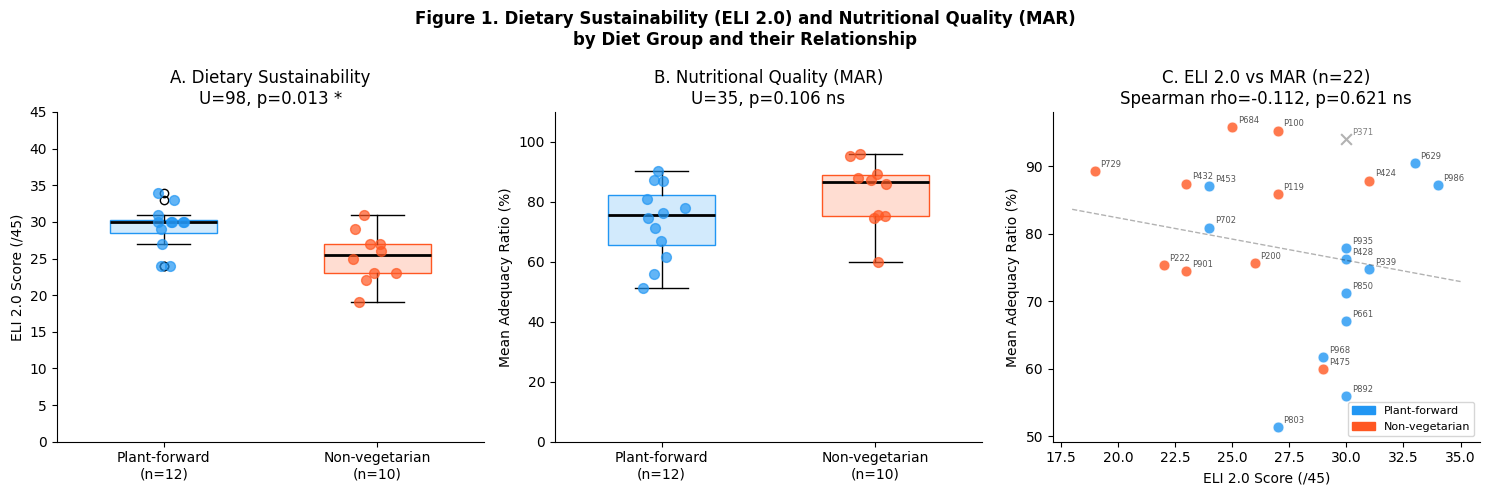

In [32]:
# Figure 1: Boxplots comparing groups on ELI 2.0 and MAR
# Plus scatter plot showing relationship between ELI 2.0 and MAR

PR_COL = '#2196F3'   # blue for plant-forward
NV_COL = '#FF5722'   # orange for non-vegetarian

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Figure 1. Dietary Sustainability (ELI 2.0) and Nutritional Quality (MAR)\n'
    'by Diet Group and their Relationship',
    fontsize=12, fontweight='bold'
)

# --- Panel A: ELI 2.0 boxplot ---
ax1 = axes[0]
np.random.seed(42)
bp1 = ax1.boxplot(
    [pr['ELI_score'].dropna(), nv['ELI_score'].dropna()],
    patch_artist=True, widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)
bp1['boxes'][0].set_facecolor(PR_COL + '33')
bp1['boxes'][0].set_edgecolor(PR_COL)
bp1['boxes'][1].set_facecolor(NV_COL + '33')
bp1['boxes'][1].set_edgecolor(NV_COL)
for i, (grp, col) in enumerate([(pr, PR_COL), (nv, NV_COL)], 1):
    ax1.scatter(np.random.normal(i, 0.06, size=len(grp)),
                grp['ELI_score'], alpha=0.7, color=col, s=50, zorder=3)
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Plant-forward\n(n=12)', 'Non-vegetarian\n(n=10)'])
ax1.set_ylabel('ELI 2.0 Score (/45)')
ax1.set_ylim(0, 45)
ax1.set_title(f'A. Dietary Sustainability\nU={U1:.0f}, p={p1:.3f} *')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Panel B: MAR boxplot ---
ax2 = axes[1]
bp2 = ax2.boxplot(
    [pr['MAR'].dropna(), nv['MAR'].dropna()],
    patch_artist=True, widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)
bp2['boxes'][0].set_facecolor(PR_COL + '33')
bp2['boxes'][0].set_edgecolor(PR_COL)
bp2['boxes'][1].set_facecolor(NV_COL + '33')
bp2['boxes'][1].set_edgecolor(NV_COL)
for i, (grp, col) in enumerate([(pr, PR_COL), (nv, NV_COL)], 1):
    ax2.scatter(np.random.normal(i, 0.06, size=len(grp)),
                grp['MAR'], alpha=0.7, color=col, s=50, zorder=3)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Plant-forward\n(n=12)', 'Non-vegetarian\n(n=10)'])
ax2.set_ylabel('Mean Adequacy Ratio (%)')
ax2.set_ylim(0, 110)
ax2.set_title(f'B. Nutritional Quality (MAR)\nU={U2:.0f}, p={p2:.3f} ns')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Panel C: Scatter ELI 2.0 vs MAR ---
ax3 = axes[2]
for _, row in all22.iterrows():
    col = PR_COL if row['Group'] == 'Plant-forward' else NV_COL
    ax3.scatter(row['ELI_score'], row['MAR'],
                color=col, s=60, alpha=0.8,
                edgecolors='white', linewidth=0.5)
    ax3.annotate(f"P{int(row['PID'])}",
                 (row['ELI_score'], row['MAR']),
                 textcoords='offset points',
                 xytext=(4, 3), fontsize=6, color='#555555')

# P371 shown separately as unclassified
p371 = master[master['PID'] == 371]
ax3.scatter(p371['ELI_score'], p371['MAR'],
            color='grey', s=60, marker='x', alpha=0.6)
ax3.annotate('P371', (p371['ELI_score'].values[0], p371['MAR'].values[0]),
             textcoords='offset points', xytext=(4, 3),
             fontsize=6, color='grey')

# Regression line
valid = all22[['ELI_score', 'MAR']].dropna()
m, b, _, _, _ = stats.linregress(valid['ELI_score'], valid['MAR'])
x_line = np.linspace(valid['ELI_score'].min()-1, valid['ELI_score'].max()+1, 100)
ax3.plot(x_line, m*x_line+b, 'k--', alpha=0.3, linewidth=1)
ax3.set_xlabel('ELI 2.0 Score (/45)')
ax3.set_ylabel('Mean Adequacy Ratio (%)')
ax3.set_title(f'C. ELI 2.0 vs MAR (n=22)\nSpearman rho={rho:.3f}, p={p_rho:.3f} ns')
ax3.legend(
    handles=[
        mpatches.Patch(color=PR_COL, label='Plant-forward'),
        mpatches.Patch(color=NV_COL, label='Non-vegetarian')
    ],
    fontsize=8, loc='lower right'
)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Figure1_Results.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### Figure 2: ELI 2.0 Component Heatmap

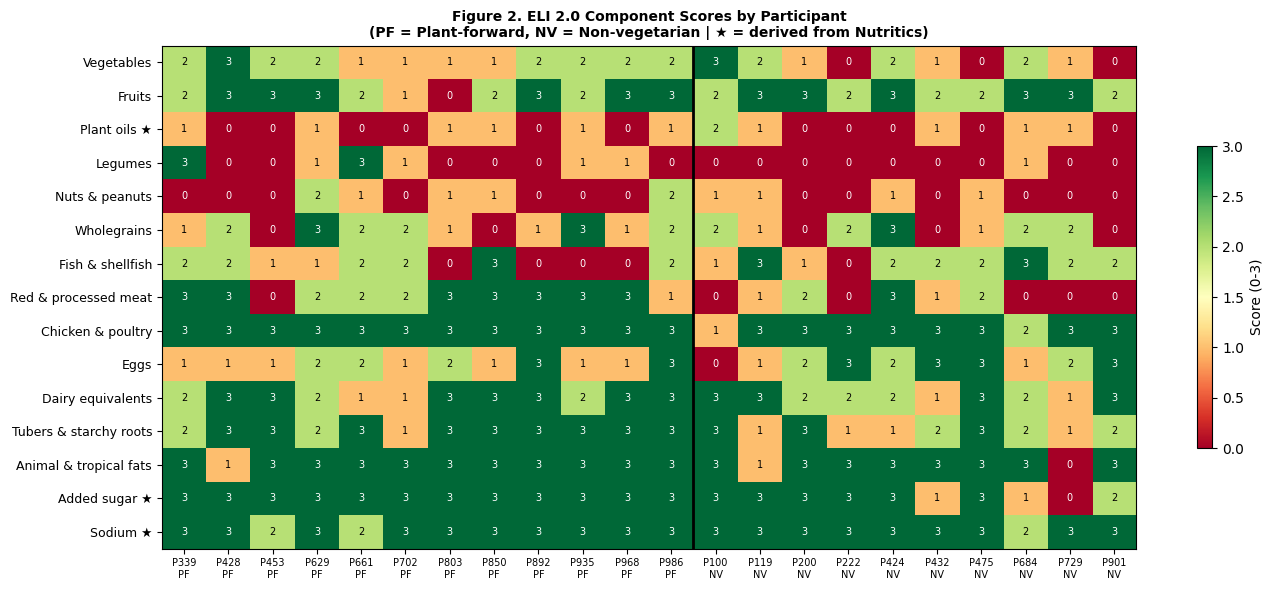

In [33]:
# Figure 2: ELI 2.0 Component Heatmap
# Shows score (0-3) for each of the 15 components per participant
# Participants ordered: plant-forward first, then non-vegetarian

COMP_ORDER = [
    'Vegetables', 'Fruits', 'Unsaturated_plant_oils', 'Legumes',
    'Tree_nuts_and_peanuts', 'Wholegrains', 'Fish_and_shellfish',
    'Beef_pork_lamb', 'Chicken_and_poultry', 'Eggs',
    'Milk_or_equivalents', 'Tubers_and_starchy_roots',
    'Animal_and_tropical_fats', 'Added_sugar', 'Sodium'
]

COMP_LABELS = {
    'Vegetables':               'Vegetables',
    'Fruits':                   'Fruits',
    'Unsaturated_plant_oils':   'Plant oils ★',
    'Legumes':                  'Legumes',
    'Tree_nuts_and_peanuts':    'Nuts & peanuts',
    'Wholegrains':              'Wholegrains',
    'Fish_and_shellfish':       'Fish & shellfish',
    'Beef_pork_lamb':           'Red & processed meat',
    'Chicken_and_poultry':      'Chicken & poultry',
    'Eggs':                     'Eggs',
    'Milk_or_equivalents':      'Dairy equivalents',
    'Tubers_and_starchy_roots': 'Tubers & starchy roots',
    'Animal_and_tropical_fats': 'Animal & tropical fats',
    'Added_sugar':              'Added sugar ★',
    'Sodium':                   'Sodium ★'
}

# Order participants: plant-forward then non-vegetarian
pf_pids = sorted(pf['PID'].tolist())
nv_pids = sorted(nv['PID'].tolist())
pids_ordered = pf_pids + nv_pids
groups_ordered = ['PF'] * len(pf_pids) + ['NV'] * len(nv_pids)

# Build matrix of scores
matrix = []
for comp in COMP_ORDER:
    row = []
    for pid in pids_ordered:
        score = eli_scores[pid].get(comp, np.nan)
        row.append(score)
    matrix.append(row)

mat = np.array(matrix, dtype=float)

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=3, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.6, label='Score (0-3)')

ax.set_yticks(range(len(COMP_ORDER)))
ax.set_yticklabels([COMP_LABELS[c] for c in COMP_ORDER], fontsize=9)
ax.set_xticks(range(len(pids_ordered)))
ax.set_xticklabels(
    [f"P{p}\n{g}" for p, g in zip(pids_ordered, groups_ordered)],
    fontsize=7
)

# Add score values inside cells
for i in range(len(COMP_ORDER)):
    for j in range(len(pids_ordered)):
        val = mat[i, j]
        if not np.isnan(val):
            ax.text(j, i, str(int(val)), ha='center', va='center',
                    fontsize=7,
                    color='white' if val in [0, 3] else 'black')

# Dividing line between groups
ax.axvline(x=len(pf_pids) - 0.5, color='black', linewidth=2)

ax.set_title(
    'Figure 2. ELI 2.0 Component Scores by Participant\n'
    '(PF = Plant-forward, NV = Non-vegetarian | ★ = derived from Nutritics)',
    fontsize=10, fontweight='bold'
)

plt.tight_layout()
plt.savefig('Figure2_ELI_Heatmap.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

### Figure 3: Nutrient Adequacy Ratios by Diet Group

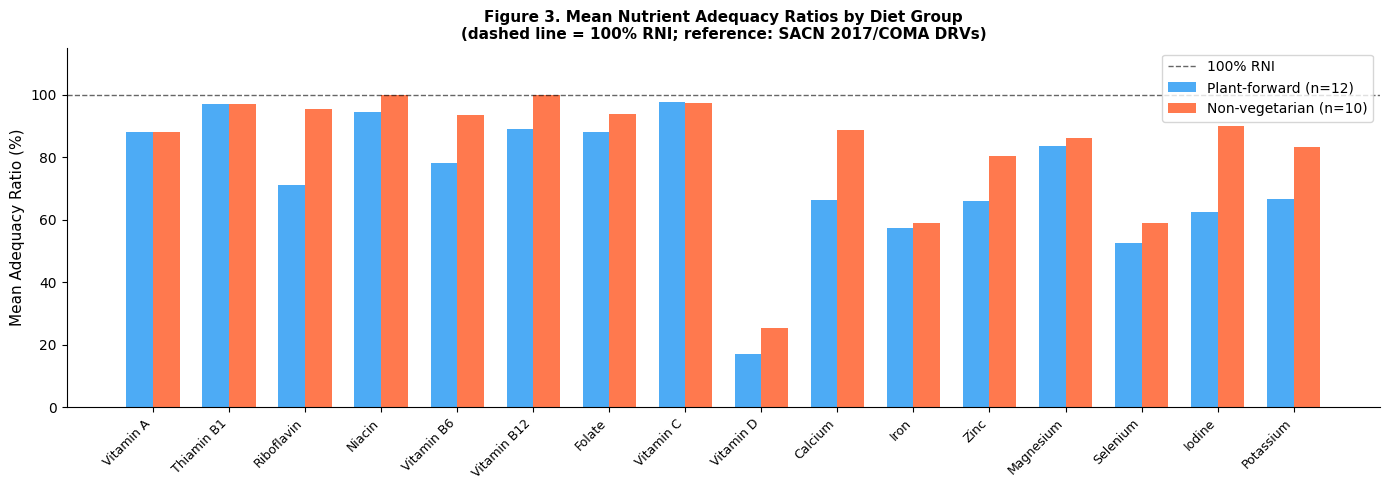

In [34]:
# Figure 3: Mean Nutrient Adequacy Ratios by Diet Group
# Shows how each of the 16 nutrients compares between groups
# Dashed line at 100% = meeting the RNI

nutrient_labels = [name for col, (name, rni) in DRV.items()]
pr_means = []
nv_means = []

for col, (name, rni) in DRV.items():
    for means_list, grp in [(pr_means, pr), (nv_means, nv)]:
        ars = []
        for pid in grp['PID']:
            nut_row = nutritics[nutritics['PID'] == pid]
            if len(nut_row) == 0:
                continue
            intake = pd.to_numeric(nut_row[col].values[0], errors='coerce')
            if pd.notna(intake):
                ars.append(min(intake / rni * 100, 100))
        means_list.append(np.mean(ars) if ars else np.nan)

x = np.arange(len(nutrient_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - w/2, pr_means, w,
       label='Plant-forward (n=12)', color='#2196F3', alpha=0.8)
ax.bar(x + w/2, nv_means, w,
       label='Non-vegetarian (n=10)', color='#FF5722', alpha=0.8)

ax.axhline(y=100, color='black', linestyle='--',
           linewidth=1, alpha=0.6, label='100% RNI')

ax.set_xticks(x)
ax.set_xticklabels(nutrient_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Adequacy Ratio (%)', fontsize=11)
ax.set_title(
    'Figure 3. Mean Nutrient Adequacy Ratios by Diet Group\n'
    '(dashed line = 100% RNI; reference: SACN 2017/COMA DRVs)',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_ylim(0, 115)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Figure3_MAR_Nutrients.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

### Figure 4: Dietary Carbon Footprint by Group and Correlations

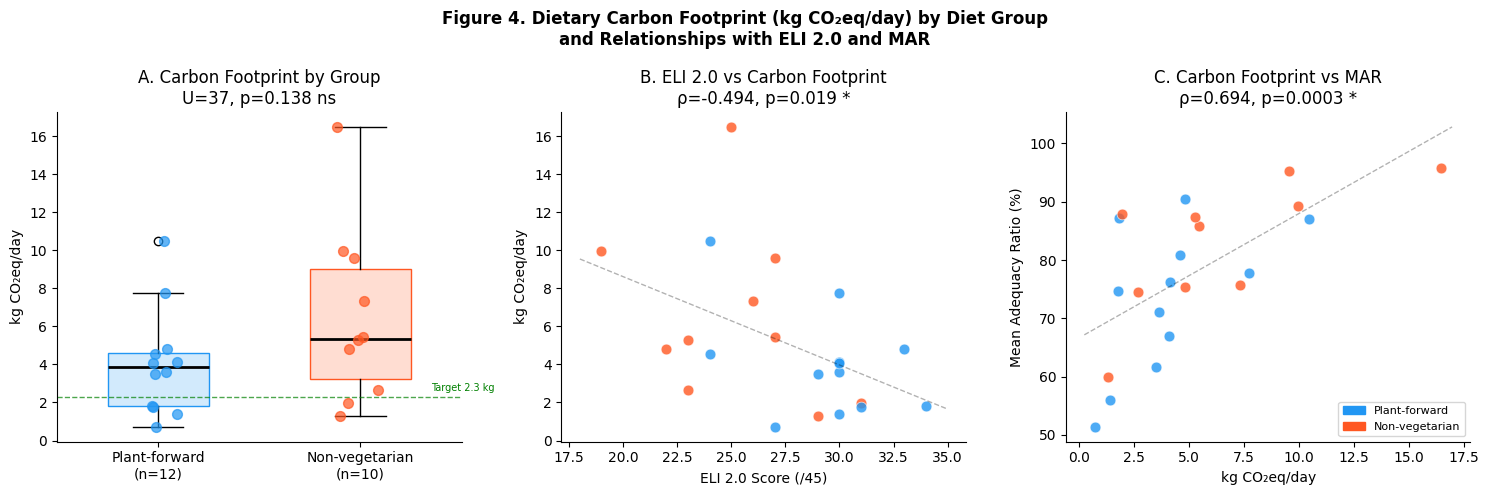

In [35]:
# Figure 4: Carbon footprint by diet group and correlations

valid = all22[['ELI_score', 'MAR', 'CO2_kgday']].dropna().copy()
valid['Group'] = all22.loc[valid.index, 'Group']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 4. Dietary Carbon Footprint (kg CO₂eq/day) by Diet Group\n'
             'and Relationships with ELI 2.0 and MAR',
             fontsize=12, fontweight='bold')

PR_COL = '#2196F3'
NV_COL = '#FF5722'
np.random.seed(42)

# Panel A: CO2 boxplot by group
ax1 = axes[0]
pr_co2 = pr['CO2_kgday'].dropna()
nv_co2 = nv['CO2_kgday'].dropna()
U, p = stats.mannwhitneyu(pr_co2, nv_co2, alternative='two-sided')
r = 1 - (2*U)/(len(pr_co2)*len(nv_co2))
bp = ax1.boxplot([pr_co2, nv_co2], patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(PR_COL + '33')
bp['boxes'][0].set_edgecolor(PR_COL)
bp['boxes'][1].set_facecolor(NV_COL + '33')
bp['boxes'][1].set_edgecolor(NV_COL)
for i, (grp, col) in enumerate([(pr, PR_COL), (nv, NV_COL)], 1):
    ax1.scatter(np.random.normal(i, 0.06, size=len(grp)),
                grp['CO2_kgday'], alpha=0.7, color=col, s=50, zorder=3)
ax1.axhline(y=2.3, color='green', linestyle='--', linewidth=1, alpha=0.7)
ax1.text(2.35, 2.6, 'Target 2.3 kg', fontsize=7, color='green')
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Plant-forward\n(n=12)', 'Non-vegetarian\n(n=10)'])
ax1.set_ylabel('kg CO₂eq/day')
ax1.set_title(f'A. Carbon Footprint by Group\nU={U:.0f}, p={p:.3f} ns')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Panel B: ELI 2.0 vs CO2
ax2 = axes[1]
rho_eli, p_eli = stats.spearmanr(valid['ELI_score'], valid['CO2_kgday'])
for _, row in valid.iterrows():
    col = PR_COL if row['Group'] == 'Plant-forward' else NV_COL
    ax2.scatter(row['ELI_score'], row['CO2_kgday'],
                color=col, s=60, alpha=0.8, edgecolors='white', linewidth=0.5)
m, b, _, _, _ = stats.linregress(valid['ELI_score'], valid['CO2_kgday'])
x_line = np.linspace(valid['ELI_score'].min()-1, valid['ELI_score'].max()+1, 100)
ax2.plot(x_line, m*x_line+b, 'k--', alpha=0.3, linewidth=1)
ax2.set_xlabel('ELI 2.0 Score (/45)')
ax2.set_ylabel('kg CO₂eq/day')
ax2.set_title(f'B. ELI 2.0 vs Carbon Footprint\nρ={rho_eli:.3f}, p={p_eli:.3f} *')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel C: MAR vs CO2
ax3 = axes[2]
rho_mar, p_mar = stats.spearmanr(valid['CO2_kgday'], valid['MAR'])
for _, row in valid.iterrows():
    col = PR_COL if row['Group'] == 'Plant-forward' else NV_COL
    ax3.scatter(row['CO2_kgday'], row['MAR'],
                color=col, s=60, alpha=0.8, edgecolors='white', linewidth=0.5)
m2, b2, _, _, _ = stats.linregress(valid['CO2_kgday'], valid['MAR'])
x_line2 = np.linspace(valid['CO2_kgday'].min()-0.5, valid['CO2_kgday'].max()+0.5, 100)
ax3.plot(x_line2, m2*x_line2+b2, 'k--', alpha=0.3, linewidth=1)
ax3.set_xlabel('kg CO₂eq/day')
ax3.set_ylabel('Mean Adequacy Ratio (%)')
ax3.set_title(f'C. Carbon Footprint vs MAR\nρ={rho_mar:.3f}, p={p_mar:.4f} *')
ax3.legend(handles=[
    mpatches.Patch(color=PR_COL, label='Plant-forward'),
    mpatches.Patch(color=NV_COL, label='Non-vegetarian')
], fontsize=8, loc='lower right')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Figure4_Foodprint.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()